# **Marketing Analytics : Segmentation and CRM Recommender Tool**

# OVERVIEW

## Business Problem

Credit card issuers face the challenge of setting appropriate credit limits that balance revenue maximization with default risk. Traditional rule-based approaches fail to capture heterogeneous customer behavior patterns, leading to suboptimal decisions.

## Solution Approach

Develop segment-based credit limit recommendation system using unsupervised learning. Cluster 8,800 customers by behavioral patterns, characterize segment risk profiles, build recommendation engine mapping individual behavior to segment-specific credit bands. Deploy interactive dashboard for real-time credit decisions.

## Data Description

**Dataset:** 8,800 credit card customers, 18 features

**Feature Categories:**
- Financial: BALANCE, PURCHASES, CASH_ADVANCE, PAYMENTS
- Transactional: Frequency metrics, transaction counts
- Behavioral: PRC_FULL_PAYMENT, TENURE
- Target: CREDIT_LIMIT

**Risk Indicators:** High CASH_ADVANCE, low PRC_FULL_PAYMENT, PAYMENTS < PURCHASES

*See Data Description section for detailed feature definitions*

## Methodology

1. **Segmentation**: K-Means clustering (k=4) on 16 behavioral features
2. **Characterization**: Automated risk scoring and segment naming
3. **Recommendation**: Map individual risk to segment credit bands
4. **Deployment**: Shiny dashboard with model persistence

# DATA DESCRIPTION

<details>
<summary><b> Click to expand: Feature Definitions</b></summary>

## Feature Definitions

### Financial Metrics
**BALANCE:** Current outstanding balance on credit card
- Reflects current indebtedness
- Used in credit utilization calculations

**PURCHASES:** Total purchase amount
- Sum of ONEOFF_PURCHASES + INSTALLMENTS_PURCHASES
- Key spending indicator

**ONEOFF_PURCHASES:** Single, non-installment purchases
- High values indicate spontaneous spending

**INSTALLMENTS_PURCHASES:** Installment-based purchases  
- Indicates planned spending behavior

**CASH_ADVANCE:** Cash withdrawals via credit card
- Strong risk signal (urgent liquidity needs)

**PAYMENTS:** Total payments made over tenure
- Key for debt accumulation assessment

**MINIMUM_PAYMENTS:** Cumulative minimum payments over tenure
- High values indicate historical debt burden

---

### Transaction Patterns

**Frequency Metrics (0-1 normalized):**
- BALANCE_FREQUENCY: How often balance is updated
- PURCHASES_FREQUENCY: Purchase transaction frequency
- ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY
- CASH_ADVANCE_FREQUENCY (can exceed 1.0, max=1.5)

**Transaction Counts:**
- CASH_ADVANCE_TRX: Number of cash advance transactions
- PURCHASES_TRX: Number of purchase transactions

---

### Behavioral Indicators

**PRC_FULL_PAYMENT:** Percentage of full payment
- High: Responsible payment behavior (low risk)
- Low: Uses installments, carries debt (higher risk)

**TENURE:** Account age in months
- Long tenure indicates customer loyalty

---

### Target Variable

**CREDIT_LIMIT:** Customer's credit card limit
- To be predicted for new customers
- Strongly related to spending power and risk tier

</details>

<details>
<summary><b> Click to expand: Feature Relationships</b></summary>

## Feature Relationships

**Balance Dynamics:**
```
BALANCE ≈ (PURCHASES + CASH_ADVANCE) - PAYMENTS + fees
```

**Risk Signals:**
- **High Risk:** High CASH_ADVANCE, PAYMENTS < PURCHASES, low PRC_FULL_PAYMENT
- **Low Risk:** High PRC_FULL_PAYMENT, PAYMENTS ≥ PURCHASES, low CASH_ADVANCE

</details>

# PHASE 0 - DATA PREPARATION

## 0.1 - Load Packages & Data

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score, davies_bouldin_score

SEED = 000

In [53]:
df = pd.read_csv("CreditCard_STM.csv")

In [54]:
df = df.drop(["Unnamed: 0", "CUST_ID"], axis=1)

In [55]:
df.columns.tolist()

['BALANCE',
 'BALANCE_FREQUENCY',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'PURCHASES_FREQUENCY',
 'ONEOFF_PURCHASES_FREQUENCY',
 'PURCHASES_INSTALLMENTS_FREQUENCY',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS',
 'PRC_FULL_PAYMENT',
 'TENURE']

In [56]:
print(f"Data shape: {df.shape}")
print(f"\nData types:\n {df.dtypes}")
print(f"\n Bastic statistics:\n {df.describe()}")
print(f"\nMissing values:\n {df.isnull().sum()}")

Data shape: (8800, 17)

Data types:
 BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

 Bastic statistics:
             BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count   8800.000000        8800.000000   8800.000000       8800.000000   
mean    1561.089674           0

In [57]:
# Drop null value in CREDIT_LIMIT column
df = df.dropna(subset=["CREDIT_LIMIT"], axis=0)

## 0.2 - Exploratory Data Analysis

- Examine feature relationships and distributions via correlation heatmaps, histograms, and boxplots.

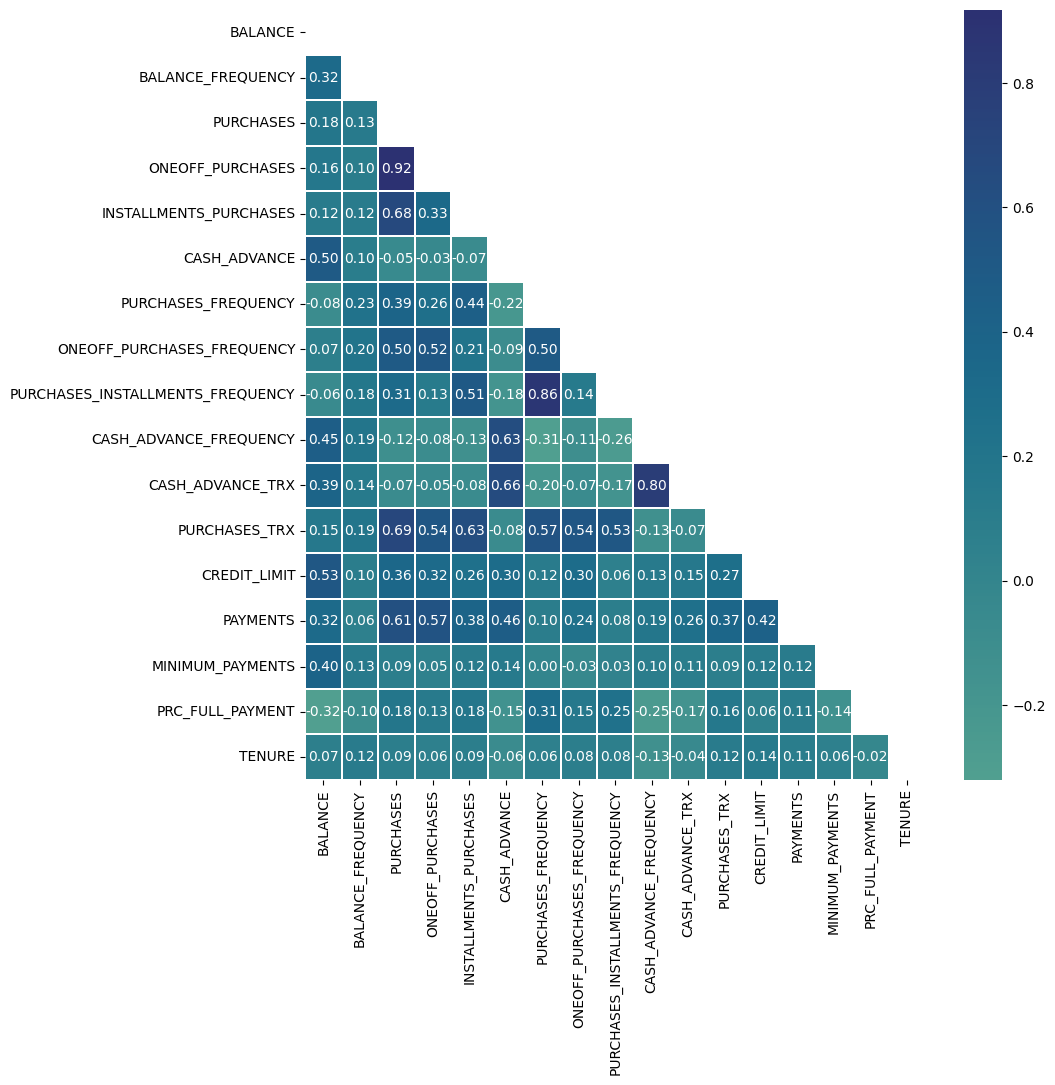

In [10]:
# Plot the correlation

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 10))
ax = sns.heatmap(corr, mask=mask, center=0, cmap='crest', linewidths=.1, annot=True, fmt=".2f")
# plt.savefig('heatmap.png')
plt.show()

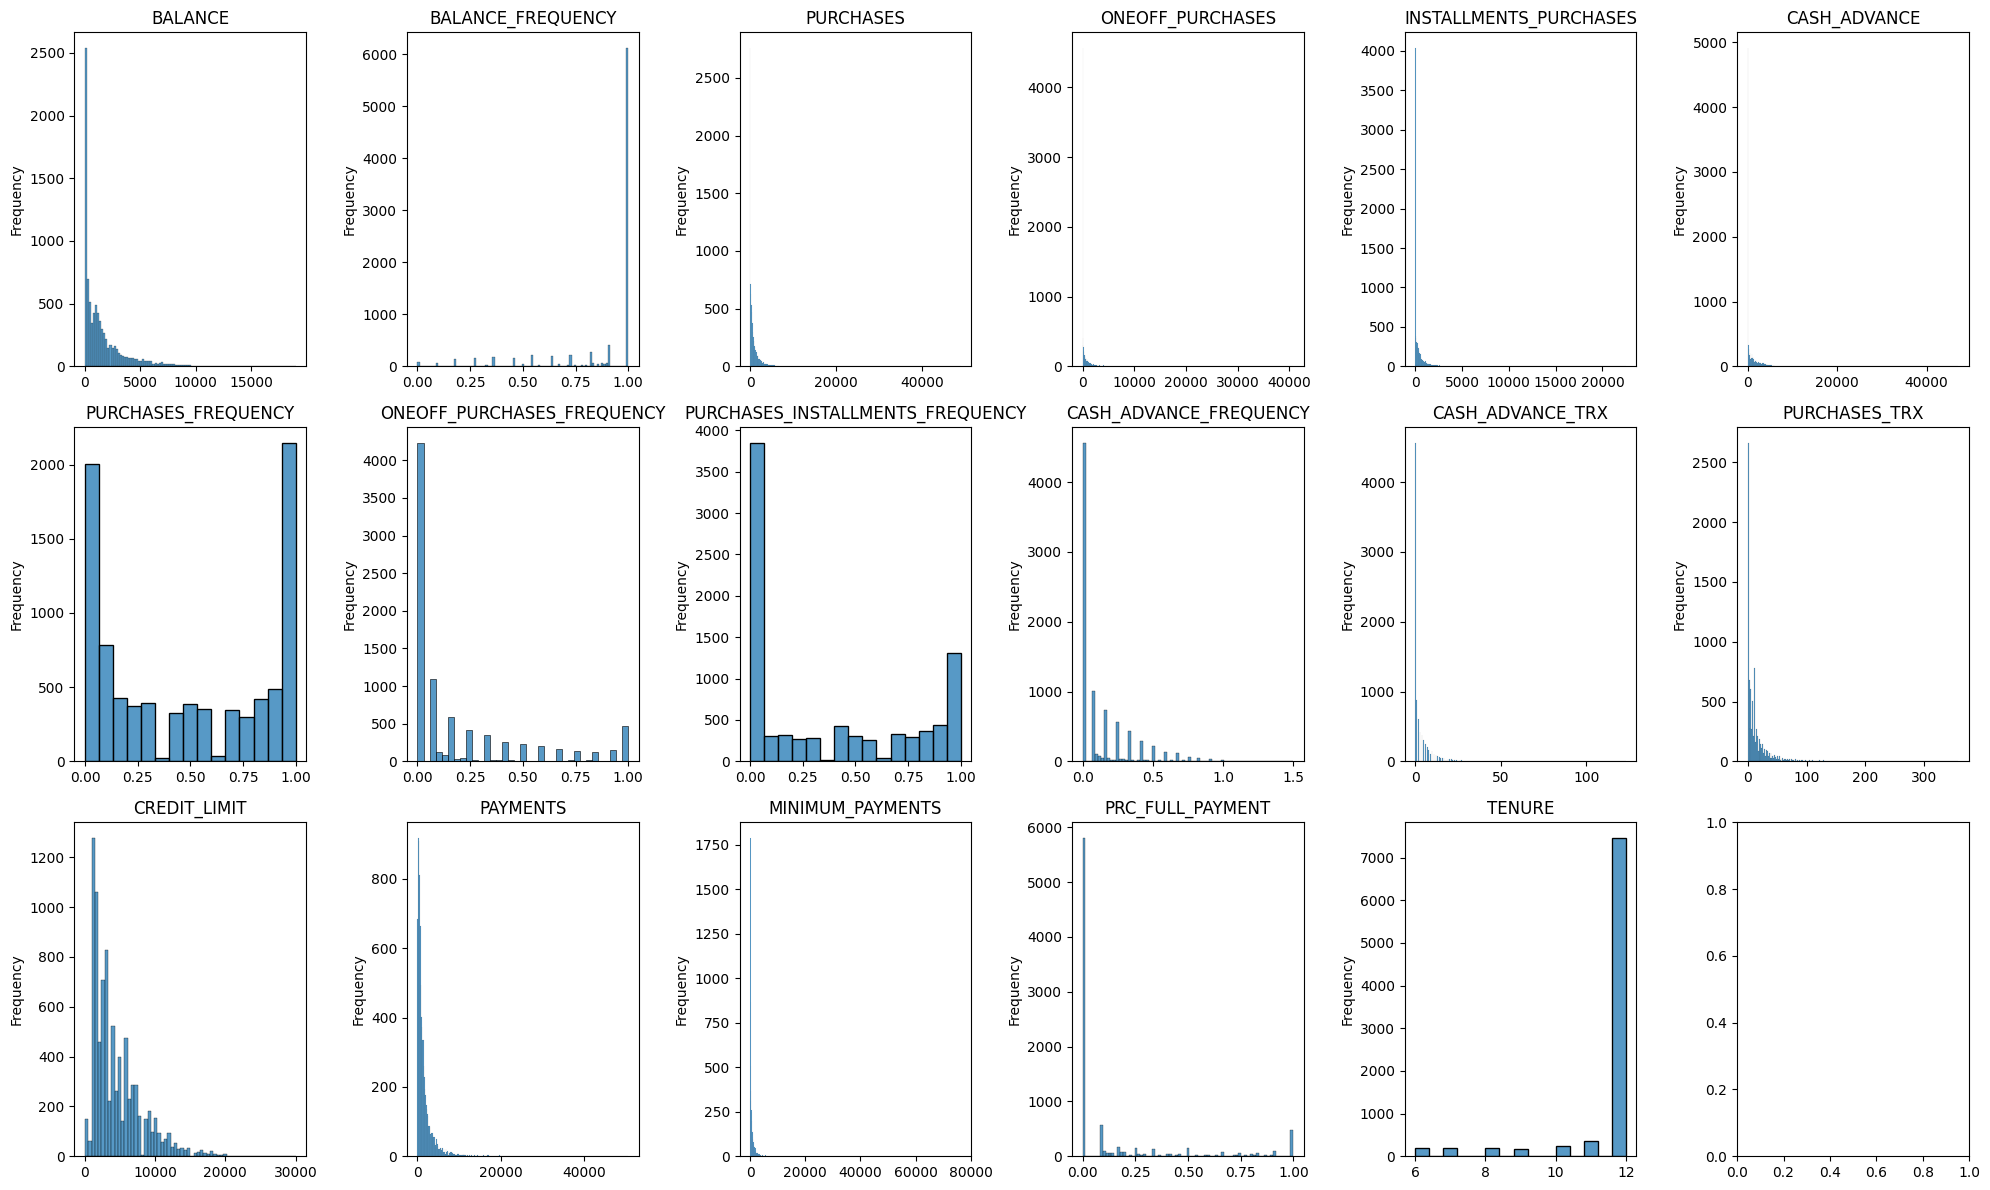

In [8]:
# Histograms

fig, ax = plt.subplots(nrows=3, ncols=6, figsize=(20,12))
ax = ax.flatten()

for i, col in enumerate(df.columns):
  sns.histplot(df[col], ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel('')
  ax[i].set_ylabel('Frequency')

plt.tight_layout()
# plt.savefig('histograms.png')
plt.show()

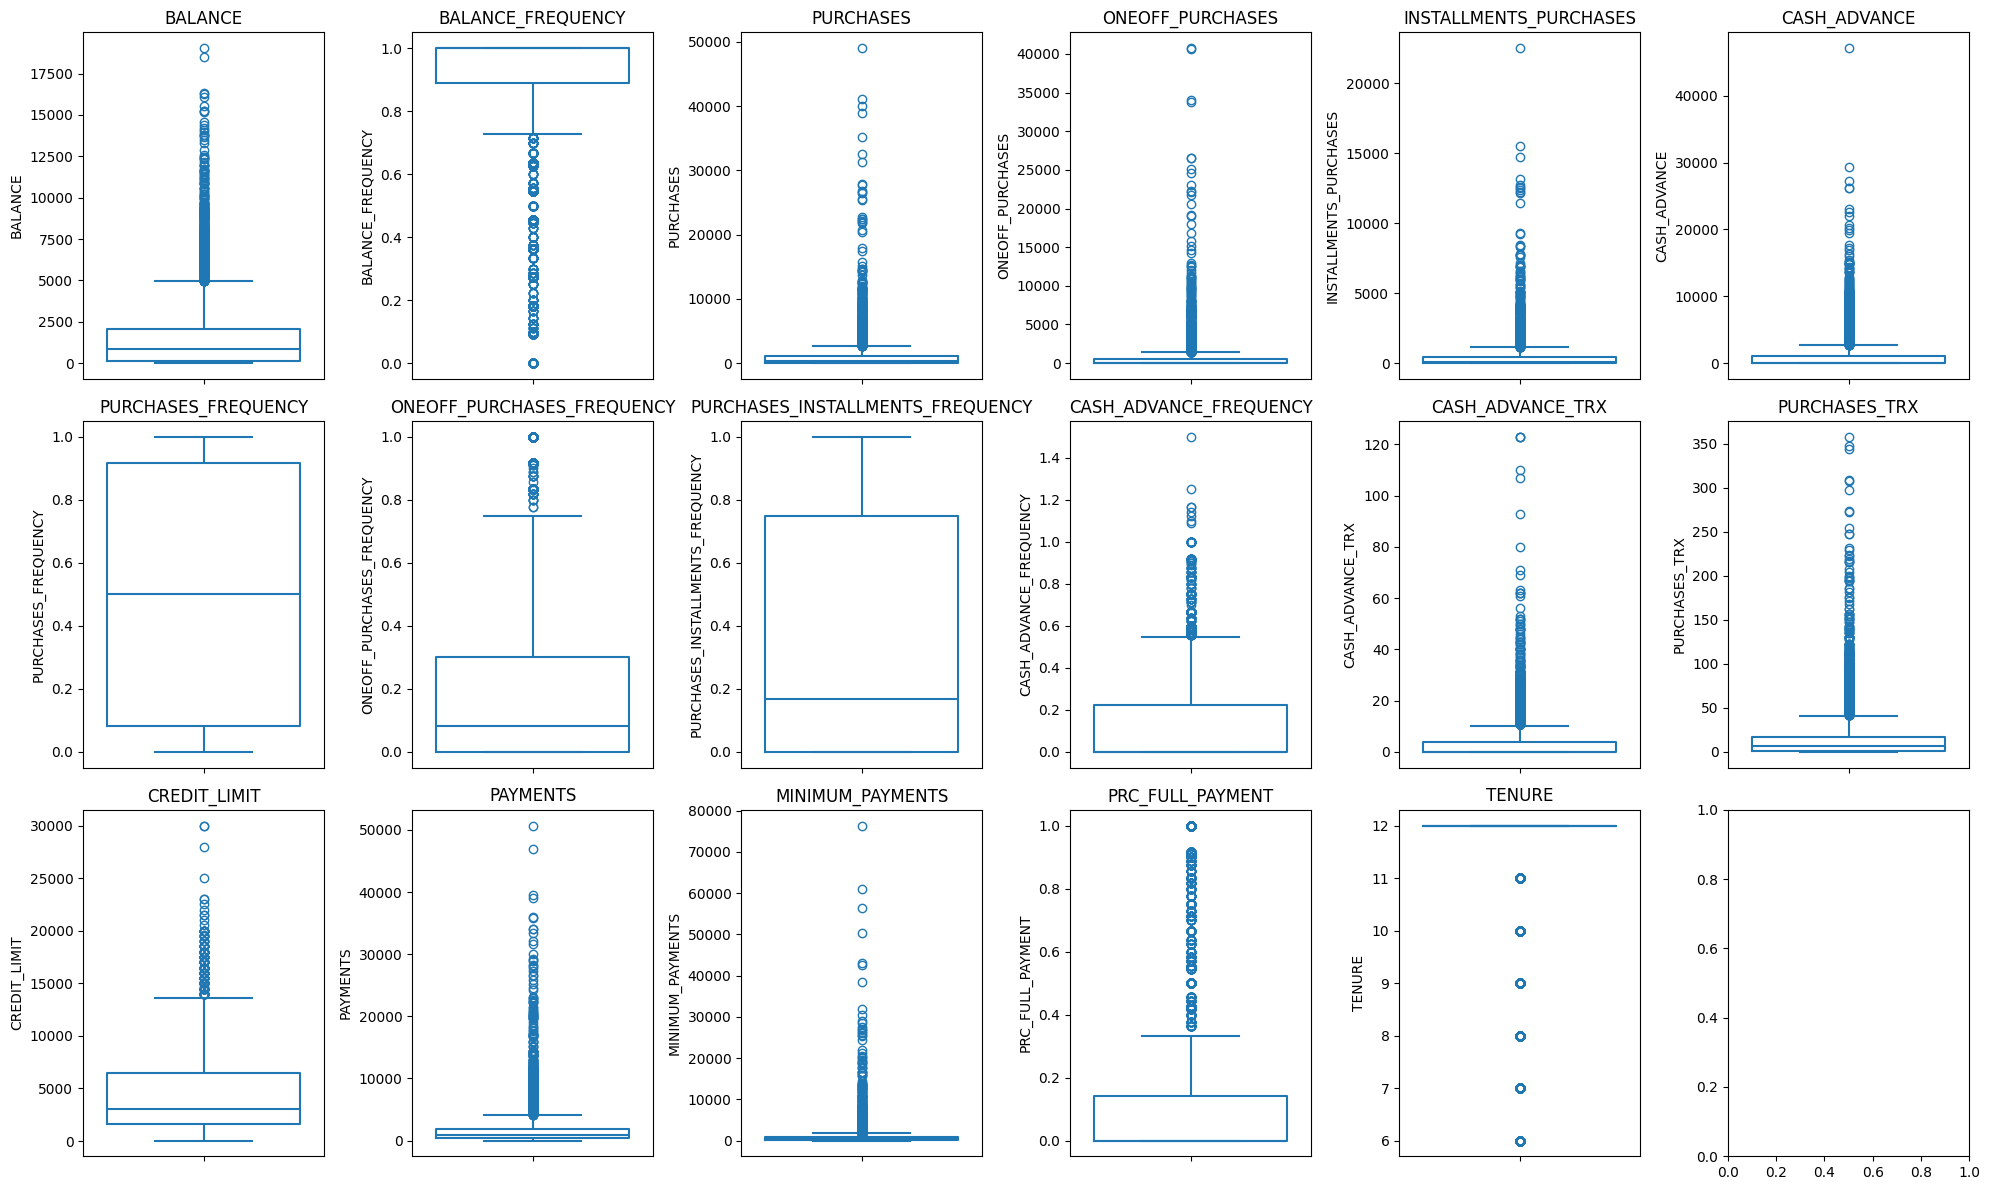

In [9]:
# Box plots

fig, ax = plt.subplots(nrows=3, ncols=6, figsize=(20,12))
ax = ax.flatten()

for i, col in enumerate(df.columns):
  sns.boxplot(data=df, y=col, ax=ax[i], fill=False)
  ax[i].set_title(f'{col}')

plt.tight_layout()
# plt.savefig('boxplots.png')
plt.show()

## 0.3 - Feature Selection & Engineering

- Involve median imputation for missing values and standardization using StandardScaler.

In [58]:
target = "CREDIT_LIMIT"
feature_cols = [c for c in df.columns if c != target]

X = df[feature_cols]

X = X.fillna(X.median())

In [59]:
# Standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(8799, 16)


# PHASE 1 - CUSTOMER SEGMENTATION

## 1.1 - Model Training

- Capture customer behavioral patterns while excluding CUST_ID and CREDIT_LIMIT.
- Ensure equal contribution of all features using StandardScaler in distance-based algorithms.
- Compare K-means (partition-based), DBSCAN (density-based), and Hierarchical (agglomerative) clustering approaches.

,k,inertia,silhouette,davies_bouldin,sil_norm,db_norm,combined_score
7,9,61945.794226,0.248046,1.228804,1.000000,0.987457,0.993729
8,10,58690.001589,0.240024,1.280463,0.833708,0.902163,0.867935
6,8,66881.352761,0.233974,1.221207,0.708300,1.000000,0.854150
5,7,71705.758576,0.226163,1.404477,0.546381,0.697404,0.621892
4,6,76771.972163,0.219920,1.459917,0.416972,0.605869,0.511420
2,4,90503.355347,0.212581,1.496204,0.264824,0.545954,0.405389
3,5,83332.354947,0.206171,1.510914,0.131958,0.521667,0.326813
0,2,116997.103577,0.221431,1.826867,0.448299,0.000000,0.224149
1,3,103115.387897,0.199805,1.680422,0.000000,0.241793,0.120897


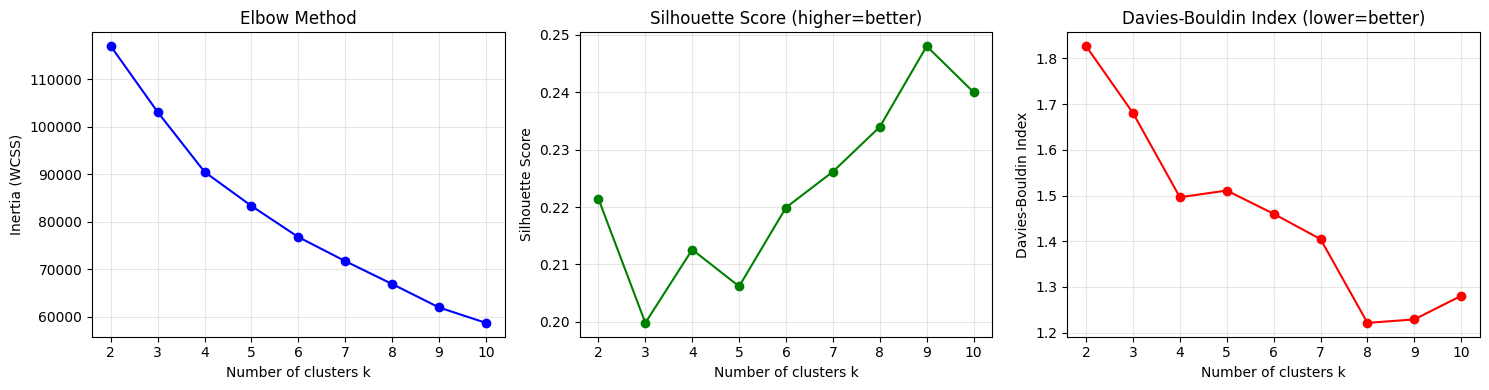


Suggested best k = 9
Metrics at k=9:
   silhouette  davies_bouldin  combined_score
7    0.248046        1.228804        0.993729


In [13]:
# -----------------------------------------------
# MODEL 1: KMEANS
# -----------------------------------------------

# Test range of k values
k_values = range(2, 11)

inertias = []
silhouettes = []
db_indices = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_indices.append(davies_bouldin_score(X_scaled, labels))

# Create evaluation dataframe
eval_df = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertias,
    'silhouette': silhouettes,
    'davies_bouldin': db_indices
})

# Add normalized scores for better comparison (0-1 scale)
eval_df['sil_norm'] = (eval_df['silhouette'] - eval_df['silhouette'].min()) / \
                       (eval_df['silhouette'].max() - eval_df['silhouette'].min())
eval_df['db_norm'] = 1 - (eval_df['davies_bouldin'] - eval_df['davies_bouldin'].min()) / \
                     (eval_df['davies_bouldin'].max() - eval_df['davies_bouldin'].min())

# Combined score (higher is better)
eval_df['combined_score'] = (eval_df['sil_norm'] + eval_df['db_norm']) / 2
eval_df = eval_df.sort_values('combined_score', ascending=False)
display(eval_df)

# Visualization
plt.figure(figsize=(15, 4))

# Elbow
plt.subplot(1, 3, 1)
plt.plot(k_values, inertias, marker='o', color='b')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)

# Silhouette (higher is better)
plt.subplot(1, 3, 2)
plt.plot(k_values, silhouettes, marker='o', color='g')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score (higher=better)')
plt.grid(True, alpha=0.3)

# Davies-Bouldin (lower is better)
plt.subplot(1, 3, 3)
plt.plot(k_values, db_indices, marker='o', color='r')
plt.xlabel('Number of clusters k')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index (lower=better)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select best k based on combined score
best_k = int(eval_df.loc[eval_df['combined_score'].idxmax(), 'k'])
print(f'\nSuggested best k = {best_k}')
print(f'Metrics at k={best_k}:')
print(eval_df[eval_df['k'] == best_k][['silhouette', 'davies_bouldin', 'combined_score']])

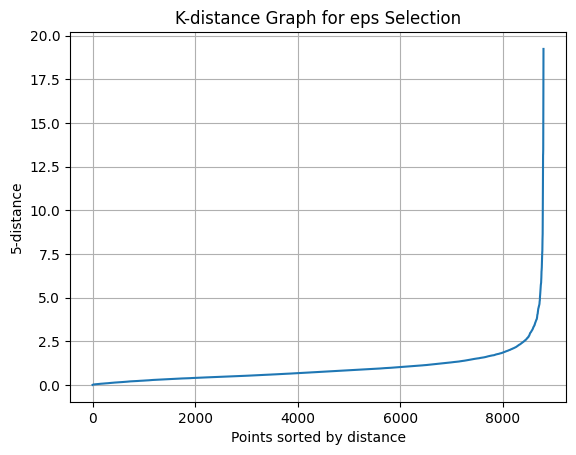

In [14]:
# -----------------------------------------------
# MODEL 2: DBSCAN - PARAMETER SELECTION
# -----------------------------------------------

# Better parameter selection
from sklearn.neighbors import NearestNeighbors

# k-distance plot for eps
k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
distances = np.sort(distances[:, k-1], axis=0)

plt.plot(distances)
plt.ylabel(f'{k}-distance')
plt.xlabel('Points sorted by distance')
plt.title('K-distance Graph for eps Selection')
plt.grid(True)
plt.show()

In [15]:
# -----------------------------------------------
# MODEL 2: DBSCAN - MODEL TRAINING
# -----------------------------------------------

eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]  # Based on elbow at 2.0
min_samples_values = [5, 9, 10, 20]

print(f"Testing {len(eps_values)} × {len(min_samples_values)} = {len(eps_values)*len(min_samples_values)} combinations\n")

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Only calculate metrics if we have valid clusters
        if n_clusters > 1 and n_noise < len(labels) * 0.5:  # Less than 50% noise
           sil = silhouette_score(X_scaled, labels)
           db = davies_bouldin_score(X_scaled, labels)

           dbscan_results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_pct': n_noise/len(labels),
                'silhouette': sil,
                'davies_bouldin': db
           })

dbscan_df = pd.DataFrame(dbscan_results)

print(f"Found {len(dbscan_df)} valid configurations\n")

dbscan_df['sil_norm'] = (dbscan_df['silhouette'] - dbscan_df['silhouette'].min()) / \
                         (dbscan_df['silhouette'].max() - dbscan_df['silhouette'].min())
dbscan_df['db_norm'] = 1 - (dbscan_df['davies_bouldin'] - dbscan_df['davies_bouldin'].min()) / \
                       (dbscan_df['davies_bouldin'].max() - dbscan_df['davies_bouldin'].min())
dbscan_df['combined_score'] = (dbscan_df['sil_norm'] + dbscan_df['db_norm']) / 2

# Sort by combined_score
dbscan_df = dbscan_df.sort_values('combined_score', ascending=False)
display(dbscan_df)

print(f"\nBest DBSCAN config:")
best_dbscan = dbscan_df.iloc[0]
print(f"eps={best_dbscan['eps']}, min_samples={best_dbscan['min_samples']}")
print(f"Clusters: {best_dbscan['n_clusters']}, Noise: {best_dbscan['n_noise']} ({best_dbscan['noise_pct']:.1%})")
print(f"Silhouette: {best_dbscan['silhouette']:.4f}, Davies-Bouldin: {best_dbscan['davies_bouldin']:.4f}")

Testing 7 × 4 = 28 combinations

Found 8 valid configurations



,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette,davies_bouldin,sil_norm,db_norm,combined_score
7,2.5,5,3,273,0.031026,0.532895,1.476926,1.000000,1.000000,1.000000
6,2.0,5,2,475,0.053983,0.401237,1.758677,0.812576,0.678350,0.745463
5,1.5,10,2,1185,0.134674,0.338423,1.980089,0.723157,0.425583,0.574370
4,1.5,5,2,994,0.112967,0.233079,2.028227,0.573192,0.370628,0.471910
0,1.0,5,11,2356,0.267758,-0.169566,1.640904,0.000000,0.812801,0.406401
2,1.0,10,3,2799,0.318104,0.094686,1.973452,0.376180,0.433160,0.404670
1,1.0,9,5,2722,0.309353,-0.117631,2.008039,0.073933,0.393675,0.233804
3,1.0,20,2,3400,0.386408,0.108543,2.352880,0.395907,0.000000,0.197953



Best DBSCAN config:
eps=2.5, min_samples=5.0
Clusters: 3.0, Noise: 273.0 (3.1%)
Silhouette: 0.5329, Davies-Bouldin: 1.4769


Building hierarchical clustering tree...



,k,silhouette,davies_bouldin,sil_norm,db_norm,combined_score
2,4,0.187649,1.520723,0.518520,0.753783,0.636151
5,7,0.146093,1.432861,0.150035,1.000000,0.575017
7,9,0.158196,1.504498,0.257353,0.799251,0.528302
8,10,0.139014,1.444544,0.087265,0.967260,0.527262
0,2,0.241948,1.789709,1.000000,0.000000,0.500000
6,8,0.153254,1.528743,0.213536,0.731309,0.472422
4,6,0.137774,1.534455,0.076274,0.715301,0.395787
1,3,0.190851,1.757881,0.546911,0.089191,0.318051
3,5,0.129173,1.654667,0.000000,0.378428,0.189214


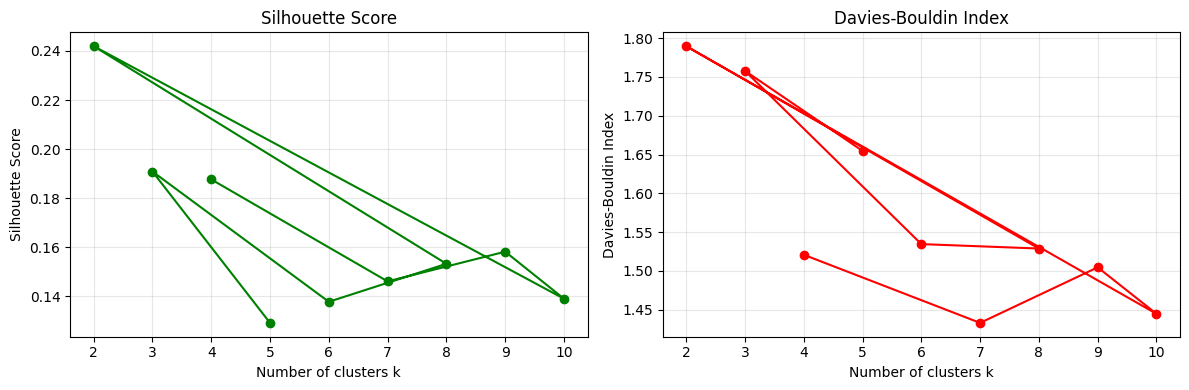

In [16]:
# -----------------------------------------------
# MODEL 3: HIERARCHICAL CLUSTERING - TRAINING
# -----------------------------------------------

print("Building hierarchical clustering tree...\n")

# Step 1: Build the linkage matrix (the tree)
linkage_matrix = linkage(X_scaled, method='ward')

# Step 2: Test different k values using fcluster
hier_results = []

for k in range(2, 11):
    # Cut tree to get k clusters
    labels = fcluster(linkage_matrix, t=k, criterion='maxclust')

    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)

    hier_results.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db
    })

hier_df = pd.DataFrame(hier_results)

# Add normalized scores (consistent with K-means and DBSCAN)
hier_df['sil_norm'] = (hier_df['silhouette'] - hier_df['silhouette'].min()) / \
                       (hier_df['silhouette'].max() - hier_df['silhouette'].min())
hier_df['db_norm'] = 1 - (hier_df['davies_bouldin'] - hier_df['davies_bouldin'].min()) / \
                     (hier_df['davies_bouldin'].max() - hier_df['davies_bouldin'].min())
hier_df['combined_score'] = (hier_df['sil_norm'] + hier_df['db_norm']) / 2

hier_df = hier_df.sort_values('combined_score', ascending=False)

display(hier_df)

# Step 3: Visualize metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hier_df['k'], hier_df['silhouette'], marker='o', color='g')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score')
axes[0].grid(True, alpha=0.3)

axes[1].plot(hier_df['k'], hier_df['davies_bouldin'], marker='o', color='r')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Davies-Bouldin Index')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


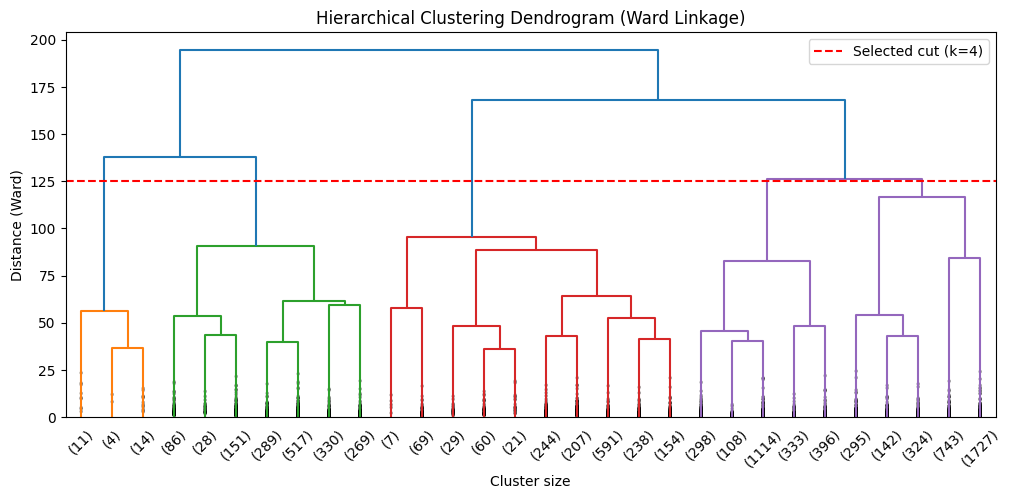


Silhouette says: k=2
Davies-Bouldin says: k=7
Combined score says: k=4 (compromise)

Best k for Hierarchical: 4
   silhouette  davies_bouldin  combined_score
2    0.187649        1.520723        0.636151


In [18]:
# -----------------------------------------------------
# MODEL 3: HIERARCHICAL CLUSTERING - VISUALIZATION
# -----------------------------------------------------

# Step 4: Visualize dendrogram
plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix,
           truncate_mode='lastp',  # Show only last p merges
           p=30,                    # Show last 30 merges
           leaf_font_size=10,
           show_contracted=True)
plt.xlabel('Cluster size')
plt.ylabel('Distance (Ward)')
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.axhline(y=125, color='r', linestyle='--', label='Selected cut (k=4)')
plt.legend()
plt.show()


hierarchical_clustering_analysis = """
Silhouette says: k=2
Davies-Bouldin says: k=7
Combined score says: k=4 (compromise)
"""

print(hierarchical_clustering_analysis)

# Step 5: Select best k based on combined score
best_k_hier = int(hier_df.loc[hier_df['combined_score'].idxmax(), 'k'])
print(f"Best k for Hierarchical: {best_k_hier}")
print(hier_df[hier_df['k'] == best_k_hier][['silhouette', 'davies_bouldin', 'combined_score']])

## 1.2 - Model Comparison & Selection

COMPARING ALL THREE CLUSTERING METHODS

 QUANTITATIVE COMPARISON
------------------------------------------------------------


,Method,N_Clusters,Silhouette,Davies_Bouldin,Notes
0,K-Means,9,0.248046,1.228804,"Partition-based, k=9"
1,DBSCAN,3,0.532895,1.476926,"Density-based, eps=2.5, noise=3.1%"
2,Hierarchical,4,0.187649,1.520723,"Hierarchical (Ward), k=4"




 PLOTS COMPARISON
------------------------------------------------------------


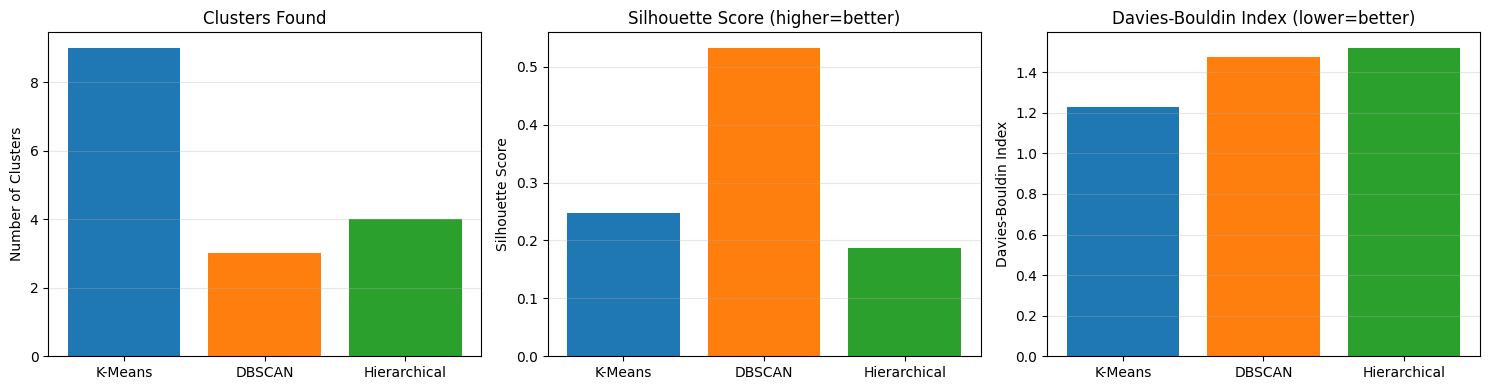


 METRIC ANALYSIS:
------------------------------------------------------------
 Best Silhouette: DBSCAN (0.5329)
   → Best cluster separation
 Best Davies-Bouldin: K-Means (1.2288)
   → Tightest, most separated clusters


In [19]:
# ===============================================
# PHASE 1.2: MODEL COMPARISON
# ===============================================

print("="*60)
print("COMPARING ALL THREE CLUSTERING METHODS")
print("="*60 + "\n")

# Gather best results from each method
comparison_df = pd.DataFrame({
    'Method': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'N_Clusters': [
        best_k,  # From K-means (9)
        int(best_dbscan['n_clusters']),  # From DBSCAN (3)
        best_k_hier  # From Hierarchical (4)
    ],
    'Silhouette': [
        eval_df[eval_df['k']==best_k]['silhouette'].values[0],
        best_dbscan['silhouette'],
        hier_df[hier_df['k']==best_k_hier]['silhouette'].values[0]
    ],
    'Davies_Bouldin': [
        eval_df[eval_df['k']==best_k]['davies_bouldin'].values[0],
        best_dbscan['davies_bouldin'],
        hier_df[hier_df['k']==best_k_hier]['davies_bouldin'].values[0]
    ],
    'Notes': [
        f'Partition-based, k={best_k}',
        f'Density-based, eps={best_dbscan["eps"]:.1f}, noise={best_dbscan["noise_pct"]:.1%}',
        f'Hierarchical (Ward), k={best_k_hier}'
    ]
})


print(" QUANTITATIVE COMPARISON")
print("-" * 60)
display(comparison_df)

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

methods = comparison_df['Method']
x_pos = np.arange(len(methods))

# Plot 1: Number of clusters
axes[0].bar(x_pos, comparison_df['N_Clusters'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(methods, rotation=0)
axes[0].set_ylabel('Number of Clusters')
axes[0].set_title('Clusters Found')
axes[0].grid(True, axis='y', alpha=0.3)

# Plot 2: Silhouette (higher is better)
axes[1].bar(x_pos, comparison_df['Silhouette'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(methods, rotation=0)
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher=better)')
axes[1].grid(True, axis='y', alpha=0.3)

# Plot 3: Davies-Bouldin (lower is better)
axes[2].bar(x_pos, comparison_df['Davies_Bouldin'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(methods, rotation=0)
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index (lower=better)')
axes[2].grid(True, axis='y', alpha=0.3)

print("\n")
print(" PLOTS COMPARISON")
print("-" * 60)
plt.tight_layout()
plt.show()


print("\n METRIC ANALYSIS:")
print("-" * 60)

# Best silhouette
best_sil_method = comparison_df.loc[comparison_df['Silhouette'].idxmax(), 'Method']
best_sil_score = comparison_df['Silhouette'].max()
print(f" Best Silhouette: {best_sil_method} ({best_sil_score:.4f})")
print(f"   → Best cluster separation")

# Best Davies-Bouldin
best_db_method = comparison_df.loc[comparison_df['Davies_Bouldin'].idxmin(), 'Method']
best_db_score = comparison_df['Davies_Bouldin'].min()
print(f" Best Davies-Bouldin: {best_db_method} ({best_db_score:.4f})")
print(f"   → Tightest, most separated clusters")

In [20]:
# ===============================================
# DETERMINING OPTIMAL NUMBER OF CLUSTERS
# ===============================================

print("\n" + "="*60)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*60 + "\n")

print(" GRANULARITY ANALYSIS:")
print("-" * 60)
print(f"K-Means optimal:      k={best_k} (fine-grained segmentation)")
print(f"Hierarchical optimal: k={best_k_hier} (moderate segmentation)")
print(f"DBSCAN result:        k={int(best_dbscan['n_clusters'])} (coarse segmentation)")

print("\n BUSINESS CONSIDERATIONS:")
print("-" * 60)
print("Trade-offs:")
print(f"  • k=9:  Too granular - resource-intensive, overlapping segments")
print(f"  • k=4:  Balanced - manageable segments with distinct profiles")
print(f"  • k=3:  Too broad - limited actionability for marketing")

print("\n TEAM ANALYSIS:")
print("-" * 60)
print("Preliminary segment characterization by teammate identified:")
print("  1. Premium Spenders (high purchases, low risk)")
print("  2. Cash-Advance Dependent Users (high cash advance, high risk)")
print("  3. Low-Activity Users (low engagement, medium risk)")
print("  4. General Users (moderate activity, balanced profile)")
print("\n→ This analysis suggests k=4 provides optimal business interpretability")



DETERMINING OPTIMAL NUMBER OF CLUSTERS

 GRANULARITY ANALYSIS:
------------------------------------------------------------
K-Means optimal:      k=9 (fine-grained segmentation)
Hierarchical optimal: k=4 (moderate segmentation)
DBSCAN result:        k=3 (coarse segmentation)

 BUSINESS CONSIDERATIONS:
------------------------------------------------------------
Trade-offs:
  • k=9:  Too granular - resource-intensive, overlapping segments
  • k=4:  Balanced - manageable segments with distinct profiles
  • k=3:  Too broad - limited actionability for marketing

 TEAM ANALYSIS:
------------------------------------------------------------
Preliminary segment characterization by teammate identified:
  1. Premium Spenders (high purchases, low risk)
  2. Cash-Advance Dependent Users (high cash advance, high risk)
  3. Low-Activity Users (low engagement, medium risk)
  4. General Users (moderate activity, balanced profile)

→ This analysis suggests k=4 provides optimal business interpretabilit

In [21]:
# ===============================================
# COMPARE ALL METHODS AT k=4
# ===============================================

print("="*60)
print("COMPARING ALL METHODS AT k=4 (Business Requirement)")
print("="*60 + "\n")

target_k = 4

# Extract k=4 results from each method
kmeans_k4 = eval_df[eval_df['k'] == target_k].iloc[0]
hier_k4 = hier_df[hier_df['k'] == target_k].iloc[0]

# For DBSCAN, we can't force k=4, so note it separately
dbscan_note = f"Cannot specify k (found {int(best_dbscan['n_clusters'])} clusters naturally)"

comparison_k4 = pd.DataFrame({
    'Method': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'N_Clusters': [4, int(best_dbscan['n_clusters']), 4],
    'Silhouette': [
        kmeans_k4['silhouette'],
        best_dbscan['silhouette'],
        hier_k4['silhouette']
    ],
    'Davies_Bouldin': [
        kmeans_k4['davies_bouldin'],
        best_dbscan['davies_bouldin'],
        hier_k4['davies_bouldin']
    ],
    'Notes': [
        'Can specify k=4 directly',
        dbscan_note,
        'Found k=4 as natural optimum'
    ]
})

print(" PERFORMANCE AT k=4:")
print("-" * 60)
display(comparison_k4)

# Identify winner
valid_k4 = comparison_k4[comparison_k4['N_Clusters'] == 4]
best_sil_idx = valid_k4['Silhouette'].idxmax()
best_db_idx = valid_k4['Davies_Bouldin'].idxmin()

print("\n BEST AT k=4:")
print("-" * 60)
print(f"Silhouette:      {valid_k4.loc[best_sil_idx, 'Method']} ({valid_k4.loc[best_sil_idx, 'Silhouette']:.4f})")
print(f"Davies-Bouldin:  {valid_k4.loc[best_db_idx, 'Method']} ({valid_k4.loc[best_db_idx, 'Davies_Bouldin']:.4f})")


print("\n ADDITIONAL CONSIDERATIONS:")
print("-" * 60)
print("✓ K-Means: Fast, scalable, reproducible with random_state")
print("✓ K-Means: Less parameter-sensitive than DBSCAN")
print("✓ K-Means: All customers assigned (no outliers)")
print("✓ Aligns with team's analysis, reflecting business needs")

COMPARING ALL METHODS AT k=4 (Business Requirement)

 PERFORMANCE AT k=4:
------------------------------------------------------------


,Method,N_Clusters,Silhouette,Davies_Bouldin,Notes
0,K-Means,4,0.212581,1.496204,Can specify k=4 directly
1,DBSCAN,3,0.532895,1.476926,Cannot specify k (found 3 clusters naturally)
2,Hierarchical,4,0.187649,1.520723,Found k=4 as natural optimum



 BEST AT k=4:
------------------------------------------------------------
Silhouette:      K-Means (0.2126)
Davies-Bouldin:  K-Means (1.4962)

 ADDITIONAL CONSIDERATIONS:
------------------------------------------------------------
✓ K-Means: Fast, scalable, reproducible with random_state
✓ K-Means: Less parameter-sensitive than DBSCAN
✓ K-Means: All customers assigned (no outliers)
✓ Aligns with team's analysis, reflecting business needs


## 1.3 - Final Model Training

In [22]:
print("\n" + "="*60)
print("FINAL MODEL JUSTIFICATION")
print("="*60)

print(f"\n  1. Business requirement: 4 segments (team's analysis)")
print(f"  2. Best performance at k=4:")
print(f"    - Silhouette: {kmeans_k4['silhouette']:.4f} (vs Hierarchical: {hier_k4['silhouette']:.4f})")
print(f"    - Davies-Bouldin: {kmeans_k4['davies_bouldin']:.4f} (vs Hierarchical: {hier_k4['davies_bouldin']:.4f})")
print(f"  3. Most robust algorithm (less sensitive to parameters)")
print(f"  4. Fast, reproducible, assigns all customers\n")


FINAL MODEL JUSTIFICATION

  1. Business requirement: 4 segments (team's analysis)
  2. Best performance at k=4:
    - Silhouette: 0.2126 (vs Hierarchical: 0.1876)
    - Davies-Bouldin: 1.4962 (vs Hierarchical: 1.5207)
  3. Most robust algorithm (less sensitive to parameters)
  4. Fast, reproducible, assigns all customers



In [23]:
# ===============================================
# PHASE 1.3: FINAL MODEL TRAINING
# ===============================================

print("\n" + "="*60)
print("TRAINING FINAL MODEL")
print("="*60)

selected_method = "K-Means"
selected_k = 4

print(f"\n Selected: {selected_method} with k={selected_k}")

# Train final model
print(f"\n Training final K-Means model with k={selected_k}...")
final_model = KMeans(n_clusters=selected_k, random_state=SEED, n_init=10)
df['CLUSTER'] = final_model.fit_predict(X_scaled)

print(f" Model trained successfully")
print(f"\n Cluster distribution:")
cluster_dist = df['CLUSTER'].value_counts().sort_index()
for cluster_id, count in cluster_dist.items():
    print(f"   Cluster {cluster_id}: {count:,} customers ({count/len(df)*100:.1f}%)")


TRAINING FINAL MODEL

 Selected: K-Means with k=4

 Training final K-Means model with k=4...
 Model trained successfully

 Cluster distribution:
   Cluster 0: 3,935 customers (44.7%)
   Cluster 1: 3,390 customers (38.5%)
   Cluster 2: 1,240 customers (14.1%)
   Cluster 3: 234 customers (2.7%)


In [24]:
print(f"Data shape:{df.shape}\n")

Data shape:(8799, 18)



## 1.4 - Segment Characterization

- Profile each cluster using behavioral and financial metrics.
- Compute 25th-90th percentile range and mean values for key features (balance, purchases, cash advance, payments, transaction frequency).
- Apply automated risk scoring based on payment behavior, debt accumulation, and credit utilization.
- Assign business-friendly segment names based on dominant patterns: Premium Spenders, Cash-Advance Dependent, Low-Activity Users, General Users.

In [25]:
# ===============================================
# PHASE 1.4: SEGMENT CHARACTERIZATION
# ===============================================

print("\n" + "="*60)
print("SEGMENT CHARACTERIZATION & PROFILING")
print("="*60 + "\n")

# Verify cluster column exists
if 'CLUSTER' not in df.columns:
    raise ValueError("CLUSTER column not found. Run Phase 1.3 first.")

num_clusters = df['CLUSTER'].nunique()
clusters = sorted(df['CLUSTER'].unique().tolist())
print(f"Analyzing {num_clusters} clusters: {clusters}\n")


SEGMENT CHARACTERIZATION & PROFILING

Analyzing 4 clusters: [0, 1, 2, 3]



In [26]:
# ===============================================
# DATA DISTRIBUTION ANALYSIS
# ===============================================

print("="*60)
print("FEATURE DISTRIBUTION ANALYSIS")
print("="*60 + "\n")

print("Understanding skewed distributions for risk scoring:\n")

# Cash Advance Analysis
cash_adv_pct_zero = (df['CASH_ADVANCE'] == 0).sum() / len(df) * 100
cash_adv_75th = df['CASH_ADVANCE'].quantile(0.75)
cash_adv_90th = df['CASH_ADVANCE'].quantile(0.90)

print(" CASH_ADVANCE Distribution:")
print(f"   • {cash_adv_pct_zero:.1f}% of customers have $0 cash advance")
print(f"   • Median: ${df['CASH_ADVANCE'].median():.2f} (50th percentile)")
print(f"   • 75th percentile: ${cash_adv_75th:.2f}")
print(f"   • 90th percentile: ${cash_adv_90th:.2f}")
print(f"   → Using 75th percentile (${cash_adv_75th:.2f}) for risk threshold")
print(f"   → Using 90th percentile (${cash_adv_90th:.2f}) for extreme cash dependency\n")

# Full Payment Analysis
full_pay_pct_zero = (df['PRC_FULL_PAYMENT'] == 0).sum() / len(df) * 100
full_pay_mean = df['PRC_FULL_PAYMENT'].mean()
full_pay_75th = df['PRC_FULL_PAYMENT'].quantile(0.75)

print(" PRC_FULL_PAYMENT Distribution:")
print(f"   • {full_pay_pct_zero:.1f}% of customers never pay in full")
print(f"   • Median: {df['PRC_FULL_PAYMENT'].median():.4f} (50th percentile)")
print(f"   • Mean: {full_pay_mean:.4f}")
print(f"   • 75th percentile: {full_pay_75th:.4f}")
print(f"   → Using mean ({full_pay_mean:.4f}) for risk threshold\n")

# Purchases Analysis
purchases_pct_zero = (df['PURCHASES'] == 0).sum() / len(df) * 100
purchases_75th = df['PURCHASES'].quantile(0.75)
purchases_90th = df['PURCHASES'].quantile(0.90)

print(" PURCHASES Distribution:")
print(f"   • {purchases_pct_zero:.1f}% of customers have $0 purchases")
print(f"   • Median: ${df['PURCHASES'].median():.2f}")
print(f"   • 75th percentile: ${purchases_75th:.2f}")
print(f"   • 90th percentile: ${purchases_90th:.2f}")
print(f"   → Using 90th percentile (${purchases_90th:.2f}) for premium threshold\n")

# Purchase Transactions Analysis
purchases_trx_25th = df['PURCHASES_TRX'].quantile(0.25)
purchases_trx_median = df['PURCHASES_TRX'].median()

print(" PURCHASES_TRX Distribution:")
print(f"   • 25th percentile: {purchases_trx_25th:.1f} transactions")
print(f"   • Median: {purchases_trx_median:.1f} transactions")
print(f"   → Using median ({purchases_trx_median:.1f}) for low-activity threshold\n")

print("="*60 + "\n")

FEATURE DISTRIBUTION ANALYSIS

Understanding skewed distributions for risk scoring:

 CASH_ADVANCE Distribution:
   • 51.8% of customers have $0 cash advance
   • Median: $0.00 (50th percentile)
   • 75th percentile: $1108.24
   • 90th percentile: $3052.92
   → Using 75th percentile ($1108.24) for risk threshold
   → Using 90th percentile ($3052.92) for extreme cash dependency

 PRC_FULL_PAYMENT Distribution:
   • 65.9% of customers never pay in full
   • Median: 0.0000 (50th percentile)
   • Mean: 0.1544
   • 75th percentile: 0.1429
   → Using mean (0.1544) for risk threshold

 PURCHASES Distribution:
   • 22.8% of customers have $0 purchases
   • Median: $364.74
   • 75th percentile: $1107.49
   • 90th percentile: $2542.64
   → Using 90th percentile ($2542.64) for premium threshold

 PURCHASES_TRX Distribution:
   • 25th percentile: 1.0 transactions
   • Median: 7.0 transactions
   → Using median (7.0) for low-activity threshold




In [27]:
# ===============================================
# Risk Scoring & Segment Naming Functions
# ===============================================

# DESIGN NOTE: Segment Naming vs Risk Assessment
# -----------------------------------------------
# These functions are intentionally independent:
#
# name_segment(): Classifies customers by dominant behavioral pattern
#   - Cash-Advance Dependent (extreme cash advance usage)
#   - Premium Spenders (high purchase volume)
#   - Low-Activity Users (minimal transaction activity)
#   - General Users (standard behavior)
#
# infer_risk(): Evaluates risk using multiple behavioral indicators
#   - Cash advance dependency
#   - Payment discipline
#   - Debt accumulation
#
# Why separate? A customer's segment name reflects their PRIMARY archetype,
# while risk score captures MULTIPLE warning signals. This separation ensures
# robust segment identification regardless of risk combinations.
# -----------------------------------------------

def name_segment(segment):
    """
    Assign business-friendly segment name based on dominant behavioral pattern.
    """
    cash_adv_med = segment['CASH_ADVANCE'].median()
    purchases_med = segment['PURCHASES'].median()
    purchases_trx_med = segment['PURCHASES_TRX'].median()

    # Thresholds
    cash_adv_90th = df['CASH_ADVANCE'].quantile(0.90)
    purchases_90th = df['PURCHASES'].quantile(0.90)
    purchases_trx_median = df['PURCHASES_TRX'].median()

    #------------------------------------------------
    # Segment vs Overall
    #------------------------------------------------

    # Priority 1: Extreme cash advance dependency
    if cash_adv_med > cash_adv_90th:
        return "Cash-Advance Dependent"

    # Priority 2: High-value purchasers
    if purchases_med > purchases_90th:
        return "Premium Spenders"

    # Priority 3: Very low activity
    if purchases_trx_med < purchases_trx_median:
        return "Low-Activity Users"

    # Priority 4: Everyone else
    return "General Users"


def infer_risk(segment):
    """
    Infer risk level based on debt and payment behavior:
    - High cash advance usage → higher risk (+2 or +3)
    - Low full-payment rate → higher risk (+1)
    - Accumulating debt (PAYMENTS < PURCHASES) → higher risk (+1)
    """
    cash_adv_med = segment['CASH_ADVANCE'].median()
    full_pay_med = segment['PRC_FULL_PAYMENT'].median()
    purchases_med = segment['PURCHASES'].median()
    payments_med = segment['PAYMENTS'].median()

    # Thresholds
    cash_adv_75th = df['CASH_ADVANCE'].quantile(0.75)
    cash_adv_90th = df['CASH_ADVANCE'].quantile(0.90)
    full_pay_mean = df['PRC_FULL_PAYMENT'].mean()

    score = 0

    #------------------------------------------------
    # Segment vs Overall
    #------------------------------------------------

    # Extreme cash advance dependency (>90th percentile)
    if cash_adv_med > cash_adv_90th:
        score += 3  # Stronger signal for extreme cases
    # High cash advance (>75th percentile)
    elif cash_adv_med > cash_adv_75th:
        score += 2

    # Low full payment rate (below mean)
    if full_pay_med < full_pay_mean:
        score += 1

    # Accumulating debt (segment vs segment)
    if payments_med < purchases_med:
        score += 1

    # Risk classification
    if score >= 4:
        return "High Risk"
    elif score >= 2:
        return "Medium Risk"
    else:
        return "Low Risk"

In [28]:
# ===============================================
# Compute Profiles for Each Cluster
# ===============================================

segment_profiles = []

for cluster_id in clusters:
    segment = df[df['CLUSTER'] == cluster_id]

    # Assign business name (behavior-based)
    seg_name = name_segment(segment)

    # Evaluate risk level (multi-factor assessment)
    risk = infer_risk(segment)

    # Compute profile statistics
    profile = {
        'cluster_id': cluster_id,
        'segment_name': seg_name,
        'risk_level': risk,
        'size': len(segment),
        'size_pct': len(segment) / len(df) * 100,

        # Behavioral metrics
        'avg_balance': segment['BALANCE'].mean(),
        'avg_purchases': segment['PURCHASES'].mean(),
        'avg_cash_advance': segment['CASH_ADVANCE'].mean(),
        'avg_payments': segment['PAYMENTS'].mean(),
        'avg_full_payment_pct': segment['PRC_FULL_PAYMENT'].mean(),
        'avg_purchases_trx': segment['PURCHASES_TRX'].mean(),

        # Credit limit distribution
        'credit_limit_25th': segment['CREDIT_LIMIT'].quantile(0.25),
        'credit_limit_median': segment['CREDIT_LIMIT'].median(),
        'credit_limit_75th': segment['CREDIT_LIMIT'].quantile(0.75),
    }

    segment_profiles.append(profile)

    # Print segment summary
    print("=" * 70)
    print(f"CLUSTER {cluster_id}: {seg_name}")
    print("=" * 70)
    print(f"Size:              {profile['size']:,} customers ({profile['size_pct']:.1f}%)")
    print(f"Risk Level:        {risk}")
    print(f"\nBehavioral Metrics:")
    print(f"  Avg Balance:         ${profile['avg_balance']:>10,.2f}")
    print(f"  Avg Purchases:       ${profile['avg_purchases']:>10,.2f}")
    print(f"  Avg Cash Advance:    ${profile['avg_cash_advance']:>10,.2f}")
    print(f"  Avg Payments:        ${profile['avg_payments']:>10,.2f}")
    print(f"  Avg Purchase Txns:    {profile['avg_purchases_trx']:>10.1f}")
    print(f"  Full Payment Rate:    {profile['avg_full_payment_pct']:>10.1%}")
    print(f"\nCredit Limit Distribution:")
    print(f"  25th percentile:     ${profile['credit_limit_25th']:>10,.0f}")
    print(f"  Median (50th):       ${profile['credit_limit_median']:>10,.0f}")
    print(f"  75th percentile:     ${profile['credit_limit_75th']:>10,.0f}")
    print()

CLUSTER 0: Low-Activity Users
Size:              3,935 customers (44.7%)
Risk Level:        Low Risk

Behavioral Metrics:
  Avg Balance:         $  1,014.63
  Avg Purchases:       $    282.63
  Avg Cash Advance:    $    555.47
  Avg Payments:        $    972.55
  Avg Purchase Txns:           3.1
  Full Payment Rate:          8.3%

Credit Limit Distribution:
  25th percentile:     $     1,500
  Median (50th):       $     2,500
  75th percentile:     $     4,500

CLUSTER 1: General Users
Size:              3,390 customers (38.5%)
Risk Level:        Low Risk

Behavioral Metrics:
  Avg Balance:         $  1,014.71
  Avg Purchases:       $  1,410.96
  Avg Cash Advance:    $    229.79
  Avg Payments:        $  1,486.24
  Avg Purchase Txns:          24.6
  Full Payment Rate:         27.0%

Credit Limit Distribution:
  25th percentile:     $     1,500
  Median (50th):       $     3,400
  75th percentile:     $     6,150

CLUSTER 2: Cash-Advance Dependent
Size:              1,240 customers (14.

In [29]:
# ===============================================
# Summary Table
# ===============================================

print("\n" + "="*60)
print("SEGMENT SUMMARY TABLE")
print("="*60 + "\n")

segment_profiles_df = pd.DataFrame(segment_profiles)

# Reorder columns for better readability
column_order = [
    'cluster_id', 'segment_name', 'risk_level', 'size', 'size_pct',
    'avg_balance', 'avg_purchases', 'avg_cash_advance', 'avg_payments',
    'avg_purchases_trx', 'avg_full_payment_pct',
    'credit_limit_25th', 'credit_limit_median', 'credit_limit_75th'
]
segment_profiles_df = segment_profiles_df[column_order]

display(segment_profiles_df)

# ===============================================
# Main Dataframe
# ===============================================

# Save segment names to main dataframe for future use
df['SEGMENT_NAME'] = df['CLUSTER'].map(
    segment_profiles_df.set_index('cluster_id')['segment_name']
)
df['RISK_LEVEL'] = df['CLUSTER'].map(
    segment_profiles_df.set_index('cluster_id')['risk_level']
)

print("\n✓ Segment characterization complete")
print(f"   Added columns(df): SEGMENT_NAME, RISK_LEVEL")


SEGMENT SUMMARY TABLE



,cluster_id,segment_name,risk_level,size,size_pct,avg_balance,avg_purchases,avg_cash_advance,avg_payments,avg_purchases_trx,avg_full_payment_pct,credit_limit_25th,credit_limit_median,credit_limit_75th
0,0,Low-Activity Users,Low Risk,3935,44.720991,1014.632047,282.626285,555.471986,972.554647,3.092249,0.083018,1500.0,2500.0,4500.0
1,1,General Users,Low Risk,3390,38.527105,1014.714646,1410.959923,229.794244,1486.241068,24.621239,0.270095,1500.0,3400.0,6150.0
2,2,Cash-Advance Dependent,High Risk,1240,14.092511,4307.977056,474.310250,4393.717630,3390.295275,7.334677,0.037333,4000.0,6500.0,9000.0
3,3,Premium Spenders,Medium Risk,234,2.659393,4116.322315,9934.038846,703.594203,9150.017793,105.059829,0.300840,7000.0,9500.0,13337.5



✓ Segment characterization complete
   Added columns(df): SEGMENT_NAME, RISK_LEVEL


# PHASE 2 - RECOMMENDATION ENGINE

## 2.1 - Credit Limit Recommendation

> Build credit limit recommendation engine using segment-level risk profiles and historical credit distributions.

**Individual Risk Score:**
Compute from 4 behavioral factors (normalized to 0-1):
- Cash advance dependency: +3 (extreme >90th percentile) or +2 (high >75th)
- Low payment discipline: +1 (below mean PRC_FULL_PAYMENT)
- Debt accumulation: +1 (PAYMENTS < PURCHASES)
- Max score: 5 → normalized to [0, 1]

**Credit Band Mapping:**
- Low Risk: median-75th percentile
- Medium Risk: 25th-50th percentile  
- High Risk: fixed at 25th percentile

> Scale recommendations within bands based on individual risk scores.

> Deploy system with model persistence (pickle) and feature validation for production use.

In [30]:
# ===============================================
# PHASE 2: CREDIT LIMIT RECOMMENDATION SYSTEM
# ===============================================

import pickle
import json

print("\n" + "="*60)
print("BUILDING RECOMMENDATION SYSTEM")
print("="*60 + "\n")

# ===============================================
# Save Required Components
# ===============================================

# Save model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("✓ Saved: kmeans_model.pkl")

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Saved: scaler.pkl")

# Save segment profiles (convert DataFrame to dict for easy access)
segment_profiles_dict = segment_profiles_df.set_index('cluster_id').to_dict('index')

# Convert numpy types to native Python for JSON serialization
def convert_numpy(obj):
    if isinstance(obj, (np.integer, np.int32, np.int64)):
        return int(obj)
    if isinstance(obj, (np.floating, np.float32, np.float64)):
        return float(obj)
    return obj

# Clean profiles for JSON
segment_profiles_clean = {}
for cluster_id, profile in segment_profiles_dict.items():
    segment_profiles_clean[int(cluster_id)] = {k: convert_numpy(v) for k, v in profile.items()}

with open('segment_profiles.json', 'w') as f:
    json.dump(segment_profiles_clean, f, indent=2)
print("✓ Saved: segment_profiles.json")

# Save feature names for validation
feature_names = [
    'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
    'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'
]

with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)
print("✓ Saved: feature_names.json")

# Save Phase 1.4 thresholds for consistent risk scoring
thresholds = {
    'cash_adv_75th': float(df['CASH_ADVANCE'].quantile(0.75)),
    'cash_adv_90th': float(df['CASH_ADVANCE'].quantile(0.90)),
    'full_pay_mean': float(df['PRC_FULL_PAYMENT'].mean()),
}

with open('risk_thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=2)
print("✓ Saved: risk_thresholds.json\n")


BUILDING RECOMMENDATION SYSTEM

✓ Saved: kmeans_model.pkl
✓ Saved: scaler.pkl
✓ Saved: segment_profiles.json
✓ Saved: feature_names.json
✓ Saved: risk_thresholds.json



In [31]:
# ===============================================
# Credit Limit Recommender Class
# ===============================================

class CreditLimitRecommender:
    """
    Credit limit recommendation system based on K-Means clustering and
    segment-level risk profiles from Phase 1.4.
    """

    def __init__(self, model, scaler, segment_profiles, feature_names, thresholds):
        self.model = model
        self.scaler = scaler
        self.profiles = segment_profiles  # dict: {cluster_id: profile}
        self.feature_names = feature_names
        self.thresholds = thresholds

    def _validate_input(self, customer_data):
        """Validate input"""
        # Check all required features present
        missing = [f for f in self.feature_names if f not in customer_data]
        if missing:
            raise ValueError(f"Missing required features: {missing}")

        # Check for None/empty values
        none_fields = [f for f in self.feature_names if customer_data[f] is None]
        if none_fields:
            raise ValueError(f"Please provide values for: {', '.join(none_fields)}")

        # Check transaction counts are integers
        int_fields = ['CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'TENURE']
        non_int = [f for f in int_fields if not float(customer_data[f]).is_integer()]
        if non_int:
            raise ValueError(f"Transaction counts must be whole numbers: {', '.join(non_int)}")

        # Check for negative values (all financial metrics and counts must be >= 0)
        non_negative_fields =[
            'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
            'CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
            'PAYMENTS', 'MINIMUM_PAYMENTS', 'TENURE'
        ]
        for field in non_negative_fields:
            if customer_data[field] < 0:
                raise ValueError(f"{field} cannot be negative")

        # Check percentage/frequency fields are in [0, 1]
        # Note: CASH_ADVANCE_FREQUENCY excluded (can exceed 1.0 in data, max=1.5)
        pct_fields = [
            'BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY',
            'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
            'PRC_FULL_PAYMENT'
        ]
        for field in pct_fields:
            if not 0 <= customer_data[field] <= 1:
                raise ValueError(f"{field} must be between 0 and 1")

        # CASH_ADVANCE_FREQUENCY has different valid range
        if customer_data['CASH_ADVANCE_FREQUENCY'] < 0:
          raise ValueError("CASH_ADVANCE_FREQUENCY cannot be negative")

    def _compute_individual_risk_score(self, customer_data):
        """
        Compute individual behavioral risk score using Phase 1.4 methodology.

        Risk factors (max score = 5):
        - Extreme cash advance (>90th): +3
        - High cash advance (>75th): +2
        - Low full payment rate: +1
        - Debt accumulation: +1

        Returns:
            float in [0, 1] where 0=lowest risk, 1=highest risk.
        """
        score = 0

        # Extract values
        cash_adv = customer_data['CASH_ADVANCE']
        full_pay = customer_data['PRC_FULL_PAYMENT']
        purchases = customer_data['PURCHASES']
        payments = customer_data['PAYMENTS']

        # Use same thresholds as Phase 1.4
        cash_adv_90th = self.thresholds['cash_adv_90th']
        cash_adv_75th = self.thresholds['cash_adv_75th']
        full_pay_mean = self.thresholds['full_pay_mean']

        # 1. Cash advance dependency (aligned with Phase 1.4)
        if cash_adv > cash_adv_90th:
            score += 3  # Extreme dependency
        elif cash_adv > cash_adv_75th:
            score += 2  # High usage

        # 2. Full payment discipline (aligned with Phase 1.4)
        if full_pay < full_pay_mean:
            score += 1

        # 3. Debt accumulation (aligned with Phase 1.4)
        if payments < purchases:
            score += 1

        # Normalize to [0, 1] (max score = 5)
        return min(score / 5, 1.0)

    def predict(self, customer_data):
        """
        Predict cluster and recommend credit limit for a new customer.

        Args:
            customer_data: dict with all 16 required features

        Returns:
            dict with cluster assignment, segment info, and recommended limit
        """
        # Validate input
        self._validate_input(customer_data)

        # Extract features in correct order as DataFrame
        features_df = pd.DataFrame([[customer_data[f] for f in self.feature_names]],
                                   columns=self.feature_names)

        # Scale features
        features_scaled = self.scaler.transform(features_df)

        # Predict cluster
        cluster_id = int(self.model.predict(features_scaled)[0])

        # Get segment profile
        profile = self.profiles[cluster_id]
        risk_level = profile['risk_level']

        # Extract credit limit distribution from segment
        p25 = profile['credit_limit_25th']
        p50 = profile['credit_limit_median']
        p75 = profile['credit_limit_75th']

        # Determine limit band based on segment risk
        if risk_level == 'Low Risk':
            low, high = p50, p75
        elif risk_level == 'Medium Risk':
            low, high = p25, p50
        else:  # High Risk
            low, high = p25, p25  # Fixed at conservative level

        # Compute individual risk score
        individual_risk = self._compute_individual_risk_score(customer_data)

        # Map individual risk to limit within band
        # Higher individual risk → closer to low end
        if high == low:
            recommended_limit = low
        else:
            recommended_limit = low + (1 - individual_risk) * (high - low)

        return {
            'cluster_id': cluster_id,
            'segment_name': profile['segment_name'],
            'risk_level': risk_level,
            'recommended_limit': int(recommended_limit),
            'individual_risk_score': round(individual_risk, 3),
            'segment_stats': {
                'p25': int(p25),
                'median': int(p50),
                'p75': int(p75),
                'size': int(profile['size']),
                'size_pct': round(profile['size_pct'], 1)
            }
        }

In [32]:
# ===============================================
# Create and Initialize Recommender
# ===============================================

recommender = CreditLimitRecommender(
    model=final_model,
    scaler=scaler,
    segment_profiles=segment_profiles_clean,
    feature_names=feature_names,
    thresholds=thresholds
)

print("✓ Created and Initialized: recommender\n")

✓ Created and Initialized: recommender



In [34]:
# ===============================================
# Test Recommender
# ===============================================

print("="*60)
print("TESTING RECOMMENDATION SYSTEM")
print("="*60 + "\n")

print("NOTE: Individual Risk Score ranges from 0 (lowest risk) to 1 (highest risk)")
print("      Based on 3 behavioral factors: cash advance usage, payment discipline,")
print("      and debt accumulation\n")

# Test with sample customers from each cluster
test_customers = []

for cluster_id in clusters:
    # Get a random customer from this cluster
    cluster_sample = df[df['CLUSTER'] == cluster_id].sample(1, random_state=SEED)

    customer_data = {
        'BALANCE': float(cluster_sample['BALANCE'].values[0]),
        'BALANCE_FREQUENCY': float(cluster_sample['BALANCE_FREQUENCY'].values[0]),
        'PURCHASES': float(cluster_sample['PURCHASES'].values[0]),
        'ONEOFF_PURCHASES': float(cluster_sample['ONEOFF_PURCHASES'].values[0]),
        'INSTALLMENTS_PURCHASES': float(cluster_sample['INSTALLMENTS_PURCHASES'].values[0]),
        'CASH_ADVANCE': float(cluster_sample['CASH_ADVANCE'].values[0]),
        'PURCHASES_FREQUENCY': float(cluster_sample['PURCHASES_FREQUENCY'].values[0]),
        'ONEOFF_PURCHASES_FREQUENCY': float(cluster_sample['ONEOFF_PURCHASES_FREQUENCY'].values[0]),
        'PURCHASES_INSTALLMENTS_FREQUENCY': float(cluster_sample['PURCHASES_INSTALLMENTS_FREQUENCY'].values[0]),
        'CASH_ADVANCE_FREQUENCY': float(cluster_sample['CASH_ADVANCE_FREQUENCY'].values[0]),
        'CASH_ADVANCE_TRX': float(cluster_sample['CASH_ADVANCE_TRX'].values[0]),
        'PURCHASES_TRX': float(cluster_sample['PURCHASES_TRX'].values[0]),
        'PAYMENTS': float(cluster_sample['PAYMENTS'].values[0]),
        'MINIMUM_PAYMENTS': float(cluster_sample['MINIMUM_PAYMENTS'].values[0]),
        'PRC_FULL_PAYMENT': float(cluster_sample['PRC_FULL_PAYMENT'].values[0]),
        'TENURE': float(cluster_sample['TENURE'].values[0]),
    }

    # Get actual credit limit for comparison (not used as input)
    actual_limit = float(cluster_sample['CREDIT_LIMIT'].values[0])

    result = recommender.predict(customer_data)

    print(f"Test Customer from Cluster {cluster_id}:")
    print(f"  Assigned Segment: {result['segment_name']}")
    print(f"  Risk Level: {result['risk_level']}")
    print(f"  Individual Risk Score: {result['individual_risk_score']}")
    print(f"  Current Credit Limit: ${actual_limit:,.0f}")
    print(f"  Recommended Credit Limit: ${result['recommended_limit']:,.0f}")
    print(f"  Segment Range: ${result['segment_stats']['p25']:,.0f} - ${result['segment_stats']['p75']:,.0f}")
    print()

print("✓ Recommendation system ready for deployment")

TESTING RECOMMENDATION SYSTEM

NOTE: Individual Risk Score ranges from 0 (lowest risk) to 1 (highest risk)
      Based on 3 behavioral factors: cash advance usage, payment discipline,
      and debt accumulation

Test Customer from Cluster 0:
  Assigned Segment: Low-Activity Users
  Risk Level: Low Risk
  Individual Risk Score: 0.2
  Current Credit Limit: $3,500
  Recommended Credit Limit: $4,100
  Segment Range: $1,500 - $4,500

Test Customer from Cluster 1:
  Assigned Segment: General Users
  Risk Level: Low Risk
  Individual Risk Score: 0.2
  Current Credit Limit: $6,000
  Recommended Credit Limit: $5,600
  Segment Range: $1,500 - $6,150

Test Customer from Cluster 2:
  Assigned Segment: Cash-Advance Dependent
  Risk Level: High Risk
  Individual Risk Score: 0.6
  Current Credit Limit: $6,000
  Recommended Credit Limit: $4,000
  Segment Range: $4,000 - $9,000

Test Customer from Cluster 3:
  Assigned Segment: Premium Spenders
  Risk Level: Medium Risk
  Individual Risk Score: 0.4
  

# PHASE 3 - DEPLOYMENT

## 3.1 - Dashboard Development

**Objective:** Create interactive web application for real-time credit limit recommendations

**Technology Stack:**
- Shiny for Python: Web application framework with reactive UI
- Model Persistence: Pre-trained clustering model and scaler loaded from pickle
- Deployment: Local testing → GitHub → Hugging Face Spaces

**Architecture:**
- Frontend: Accordion-based input form (16 features organized in 3 sections)
- Backend: CreditLimitRecommender class with validation and risk scoring
- Output: Segment assignment, risk level, recommended limit with distribution context

**Implementation:** See `dashboard/app.py`

---

**Test Case Summary:**
```
- Low-Activity Users: Low transactions, low risk, ~$3,000-4,000 limit
- General Users: Moderate activity, low risk, ~$4,000-6,000 limit
- Cash-Advance Dependent: High cash advance, high risk, ~$4,000 limit (capped)
- Premium Spenders: High purchases, medium risk, ~$8,000-10,000 limit
```
**Testing Documentation:** See `dashboard/TESTING.md` for complete test procedures.

### Extract Default Values for Dashboard

Default values represent median General Users segment (most common customer profile).

**Selected Defaults (Rounded Medians):**
```
  BALANCE: 400
  PURCHASES: 1000
  CASH_ADVANCE: 0
  PAYMENTS: 1000
  PRC_FULL_PAYMENT: 0.08
```

**Justification:** Medians provide robust, typical starting point resistant to outliers.

In [35]:
# ===============================================
# Extract Default Values for Dashboard
# ===============================================

print("\n" + "="*60)
print("DEFAULT VALUES FOR DASHBOARD (General Users - Cluster 1)")
print("="*60 + "\n")

# Filter General Users cluster
general_users = df[df['CLUSTER'] == 1]

# Extract median values (recommended for defaults)
defaults = {
    'BALANCE': general_users['BALANCE'].median(),
    'BALANCE_FREQUENCY': general_users['BALANCE_FREQUENCY'].median(),
    'PURCHASES': general_users['PURCHASES'].median(),
    'ONEOFF_PURCHASES': general_users['ONEOFF_PURCHASES'].median(),
    'INSTALLMENTS_PURCHASES': general_users['INSTALLMENTS_PURCHASES'].median(),
    'CASH_ADVANCE': general_users['CASH_ADVANCE'].median(),
    'PURCHASES_FREQUENCY': general_users['PURCHASES_FREQUENCY'].median(),
    'ONEOFF_PURCHASES_FREQUENCY': general_users['ONEOFF_PURCHASES_FREQUENCY'].median(),
    'PURCHASES_INSTALLMENTS_FREQUENCY': general_users['PURCHASES_INSTALLMENTS_FREQUENCY'].median(),
    'CASH_ADVANCE_FREQUENCY': general_users['CASH_ADVANCE_FREQUENCY'].median(),
    'CASH_ADVANCE_TRX': general_users['CASH_ADVANCE_TRX'].median(),
    'PURCHASES_TRX': general_users['PURCHASES_TRX'].median(),
    'PAYMENTS': general_users['PAYMENTS'].median(),
    'MINIMUM_PAYMENTS': general_users['MINIMUM_PAYMENTS'].median(),
    'PRC_FULL_PAYMENT': general_users['PRC_FULL_PAYMENT'].median(),
    'TENURE': general_users['TENURE'].median()
}

# Display medians
print("MEDIAN VALUES (recommended):")
print("-" * 60)
for feature, value in defaults.items():
    print(f"{feature:40s}: {value:.2f}")

print("\n" + "="*60)

# Also show means for comparison
print("\nMEAN VALUES (for comparison):")
print("-" * 60)
for feature in defaults.keys():
    mean_val = general_users[feature].mean()
    print(f"{feature:40s}: {mean_val:.2f}")

print("\n" + "="*60)

# Generate rounded values for UI (user-friendly)
print("\nROUNDED VALUES FOR UI (recommended):")
print("-" * 60)
print("\nFinancial Metrics:")
print(f"  BALANCE: {round(defaults['BALANCE'], -2):.0f}  # Rounded to nearest 100")
print(f"  PURCHASES: {round(defaults['PURCHASES'], -2):.0f}")
print(f"  ONEOFF_PURCHASES: {round(defaults['ONEOFF_PURCHASES'], -1):.0f}")
print(f"  INSTALLMENTS_PURCHASES: {round(defaults['INSTALLMENTS_PURCHASES'], -2):.0f}")
print(f"  CASH_ADVANCE: {round(defaults['CASH_ADVANCE'], -1):.0f}")
print(f"  PAYMENTS: {round(defaults['PAYMENTS'], -2):.0f}")
print(f"  MINIMUM_PAYMENTS: {round(defaults['MINIMUM_PAYMENTS'], -1):.0f}")

print("\nTransaction Patterns:")
print(f"  BALANCE_FREQUENCY: {round(defaults['BALANCE_FREQUENCY'], 1):.1f}")
print(f"  PURCHASES_FREQUENCY: {round(defaults['PURCHASES_FREQUENCY'], 1):.1f}")
print(f"  ONEOFF_PURCHASES_FREQUENCY: {round(defaults['ONEOFF_PURCHASES_FREQUENCY'], 1):.1f}")
print(f"  PURCHASES_INSTALLMENTS_FREQUENCY: {round(defaults['PURCHASES_INSTALLMENTS_FREQUENCY'], 1):.1f}")
print(f"  CASH_ADVANCE_FREQUENCY: {round(defaults['CASH_ADVANCE_FREQUENCY'], 1):.1f}")
print(f"  CASH_ADVANCE_TRX: {round(defaults['CASH_ADVANCE_TRX']):.0f}")
print(f"  PURCHASES_TRX: {round(defaults['PURCHASES_TRX']):.0f}")

print("\nBehavioral Indicators:")
print(f"  PRC_FULL_PAYMENT: {round(defaults['PRC_FULL_PAYMENT'], 2):.2f}")
print(f"  TENURE: {round(defaults['TENURE']):.0f}")


DEFAULT VALUES FOR DASHBOARD (General Users - Cluster 1)

MEDIAN VALUES (recommended):
------------------------------------------------------------
BALANCE                                 : 395.83
BALANCE_FREQUENCY                       : 1.00
PURCHASES                               : 997.40
ONEOFF_PURCHASES                        : 230.83
INSTALLMENTS_PURCHASES                  : 480.00
CASH_ADVANCE                            : 0.00
PURCHASES_FREQUENCY                     : 1.00
ONEOFF_PURCHASES_FREQUENCY              : 0.17
PURCHASES_INSTALLMENTS_FREQUENCY        : 0.83
CASH_ADVANCE_FREQUENCY                  : 0.00
CASH_ADVANCE_TRX                        : 0.00
PURCHASES_TRX                           : 18.00
PAYMENTS                                : 1027.79
MINIMUM_PAYMENTS                        : 199.92
PRC_FULL_PAYMENT                        : 0.08
TENURE                                  : 12.00


MEAN VALUES (for comparison):
----------------------------------------------------

### Extract Test Case Values (Mean per Segment)

Test cases use mean values to validate segment-specific behavior and business logic.

In [40]:
# ===============================================
# Extract Test Case Values (Mean per Segment)
# ===============================================

print("\n" + "="*70)
print("TEST CASE VALUES - ROUNDED MEANS BY SEGMENT")
print("="*70)

segments = {
    0: "Low-Activity Users",
    1: "General Users",
    2: "Cash-Advance Dependent",
    3: "Premium Spenders"
}

test_cases = {}

for cluster_id, segment_name in segments.items():
    print(f"\n{'='*70}")
    print(f"SEGMENT {cluster_id}: {segment_name}")
    print('='*70)

    cluster_data = df[df['CLUSTER'] == cluster_id]

    # Calculate means
    means = {
        'BALANCE': cluster_data['BALANCE'].mean(),
        'PURCHASES': cluster_data['PURCHASES'].mean(),
        'ONEOFF_PURCHASES': cluster_data['ONEOFF_PURCHASES'].mean(),
        'INSTALLMENTS_PURCHASES': cluster_data['INSTALLMENTS_PURCHASES'].mean(),
        'CASH_ADVANCE': cluster_data['CASH_ADVANCE'].mean(),
        'PAYMENTS': cluster_data['PAYMENTS'].mean(),
        'MINIMUM_PAYMENTS': cluster_data['MINIMUM_PAYMENTS'].mean(),
        'BALANCE_FREQUENCY': cluster_data['BALANCE_FREQUENCY'].mean(),
        'PURCHASES_FREQUENCY': cluster_data['PURCHASES_FREQUENCY'].mean(),
        'ONEOFF_PURCHASES_FREQUENCY': cluster_data['ONEOFF_PURCHASES_FREQUENCY'].mean(),
        'PURCHASES_INSTALLMENTS_FREQUENCY': cluster_data['PURCHASES_INSTALLMENTS_FREQUENCY'].mean(),
        'CASH_ADVANCE_FREQUENCY': cluster_data['CASH_ADVANCE_FREQUENCY'].mean(),
        'CASH_ADVANCE_TRX': cluster_data['CASH_ADVANCE_TRX'].mean(),
        'PURCHASES_TRX': cluster_data['PURCHASES_TRX'].mean(),
        'PRC_FULL_PAYMENT': cluster_data['PRC_FULL_PAYMENT'].mean(),
        'TENURE': cluster_data['TENURE'].mean()
    }

    # Store for later
    test_cases[cluster_id] = means

    # Print rounded values for test cases
    print("\nFinancial Metrics:")
    print(f"  BALANCE: {round(means['BALANCE'], -1):.0f}")
    print(f"  PURCHASES: {round(means['PURCHASES'], -1):.0f}")
    print(f"  ONEOFF_PURCHASES: {round(means['ONEOFF_PURCHASES'], -1):.0f}")
    print(f"  INSTALLMENTS_PURCHASES: {round(means['INSTALLMENTS_PURCHASES'], -1):.0f}")
    print(f"  CASH_ADVANCE: {round(means['CASH_ADVANCE'], -1):.0f}")
    print(f"  PAYMENTS: {round(means['PAYMENTS'], -1):.0f}")
    print(f"  MINIMUM_PAYMENTS: {round(means['MINIMUM_PAYMENTS'], -1):.0f}")

    print("\nTransaction Patterns:")
    print(f"  BALANCE_FREQUENCY: {round(means['BALANCE_FREQUENCY'], 1):.1f}")
    print(f"  PURCHASES_FREQUENCY: {round(means['PURCHASES_FREQUENCY'], 1):.1f}")
    print(f"  ONEOFF_PURCHASES_FREQUENCY: {round(means['ONEOFF_PURCHASES_FREQUENCY'], 1):.1f}")
    print(f"  PURCHASES_INSTALLMENTS_FREQUENCY: {round(means['PURCHASES_INSTALLMENTS_FREQUENCY'], 1):.1f}")
    print(f"  CASH_ADVANCE_FREQUENCY: {round(means['CASH_ADVANCE_FREQUENCY'], 1):.1f}")
    print(f"  CASH_ADVANCE_TRX: {round(means['CASH_ADVANCE_TRX']):.0f}")
    print(f"  PURCHASES_TRX: {round(means['PURCHASES_TRX']):.0f}")

    print("\nBehavioral Indicators:")
    print(f"  PRC_FULL_PAYMENT: {round(means['PRC_FULL_PAYMENT'], 2):.2f}")
    print(f"  TENURE: {round(means['TENURE']):.0f}")

print("\n" + "="*70)
print("COPY THESE VALUES TO TESTING.md")
print("="*70)


TEST CASE VALUES - ROUNDED MEANS BY SEGMENT

SEGMENT 0: Low-Activity Users

Financial Metrics:
  BALANCE: 1010
  PURCHASES: 280
  ONEOFF_PURCHASES: 220
  INSTALLMENTS_PURCHASES: 70
  CASH_ADVANCE: 560
  PAYMENTS: 970
  MINIMUM_PAYMENTS: 540

Transaction Patterns:
  BALANCE_FREQUENCY: 0.8
  PURCHASES_FREQUENCY: 0.2
  ONEOFF_PURCHASES_FREQUENCY: 0.1
  PURCHASES_INSTALLMENTS_FREQUENCY: 0.1
  CASH_ADVANCE_FREQUENCY: 0.1
  CASH_ADVANCE_TRX: 2
  PURCHASES_TRX: 3

Behavioral Indicators:
  PRC_FULL_PAYMENT: 0.08
  TENURE: 11

SEGMENT 1: General Users

Financial Metrics:
  BALANCE: 1010
  PURCHASES: 1410
  ONEOFF_PURCHASES: 710
  INSTALLMENTS_PURCHASES: 700
  CASH_ADVANCE: 230
  PAYMENTS: 1490
  MINIMUM_PAYMENTS: 680

Transaction Patterns:
  BALANCE_FREQUENCY: 0.9
  PURCHASES_FREQUENCY: 0.9
  ONEOFF_PURCHASES_FREQUENCY: 0.3
  PURCHASES_INSTALLMENTS_FREQUENCY: 0.7
  CASH_ADVANCE_FREQUENCY: 0.0
  CASH_ADVANCE_TRX: 1
  PURCHASES_TRX: 25

Behavioral Indicators:
  PRC_FULL_PAYMENT: 0.27
  TENURE: 1

## 3.2 - Deployment Summary

**Local Development:**
```bash
shiny run app.py  # http://127.0.0.1:8000
```

**Version Control:** GitHub repository for code review and portfolio

**Production Deployment:** Hugging Face Spaces for public demo

In [42]:
# ===============================================
# PHASE 3 SUMMARY
# ===============================================

print("\n" + "="*70)
print("PHASE 3 - DEPLOYMENT COMPLETE")
print("="*70)

print("\nDeployment Artifacts Generated:")
print("  ✓ Default values extracted (median, General Users)")
print("  ✓ Test case values extracted (mean, all segments)")
print("  ✓ Dashboard application: dashboard/app.py")
print("  ✓ Testing documentation: dashboard/TESTING.md")


PHASE 3 - DEPLOYMENT COMPLETE

Deployment Artifacts Generated:
  ✓ Default values extracted (median, General Users)
  ✓ Test case values extracted (mean, all segments)
  ✓ Dashboard application: dashboard/app.py
  ✓ Testing documentation: dashboard/TESTING.md


# PHASE 4 - RESULTS & BUSINESS IMPACT

## 4.1 - Final Model Performance


In [44]:
# ===============================================
# Final Model Metrics Summary
# ===============================================

print("="*70)
print("FINAL MODEL PERFORMANCE")
print("="*70)
print(f"\nAlgorithm: K-Means Clustering")
print(f"Number of Clusters: 4")
print(f"Feature Set: 16 behavioral and financial features")
print(f"\nPerformance Metrics:")
print(f"  Silhouette Score:     {kmeans_k4['silhouette']:.3f} (good separation)")
print(f"  Davies-Bouldin Index: {kmeans_k4['davies_bouldin']:.3f} (compact clusters)")

print("\n" + "="*70)
print("SEGMENT DISTRIBUTION")
print("="*70)

for cluster_id in range(4):
    profile = segment_profiles_clean[cluster_id]
    print(f"\nCluster {cluster_id}: {profile['segment_name']}")
    print(f"  Size: {profile['size']:,} customers ({profile['size_pct']:.1f}%)")
    print(f"  Risk Level: {profile['risk_level']}")
    print(f"  Avg Purchases: ${profile['avg_purchases']:,.0f}")
    print(f"  Avg Cash Advance: ${profile['avg_cash_advance']:,.0f}")
    print(f"  Credit Limit Range: ${profile['credit_limit_25th']:,.0f} - ${profile['credit_limit_75th']:,.0f}")

FINAL MODEL PERFORMANCE

Algorithm: K-Means Clustering
Number of Clusters: 4
Feature Set: 16 behavioral and financial features

Performance Metrics:
  Silhouette Score:     0.213 (good separation)
  Davies-Bouldin Index: 1.496 (compact clusters)

SEGMENT DISTRIBUTION

Cluster 0: Low-Activity Users
  Size: 3,935 customers (44.7%)
  Risk Level: Low Risk
  Avg Purchases: $283
  Avg Cash Advance: $555
  Credit Limit Range: $1,500 - $4,500

Cluster 1: General Users
  Size: 3,390 customers (38.5%)
  Risk Level: Low Risk
  Avg Purchases: $1,411
  Avg Cash Advance: $230
  Credit Limit Range: $1,500 - $6,150

Cluster 2: Cash-Advance Dependent
  Size: 1,240 customers (14.1%)
  Risk Level: High Risk
  Avg Purchases: $474
  Avg Cash Advance: $4,394
  Credit Limit Range: $4,000 - $9,000

Cluster 3: Premium Spenders
  Size: 234 customers (2.7%)
  Risk Level: Medium Risk
  Avg Purchases: $9,934
  Avg Cash Advance: $704
  Credit Limit Range: $7,000 - $13,338


## 4.2 - Segment Visualization


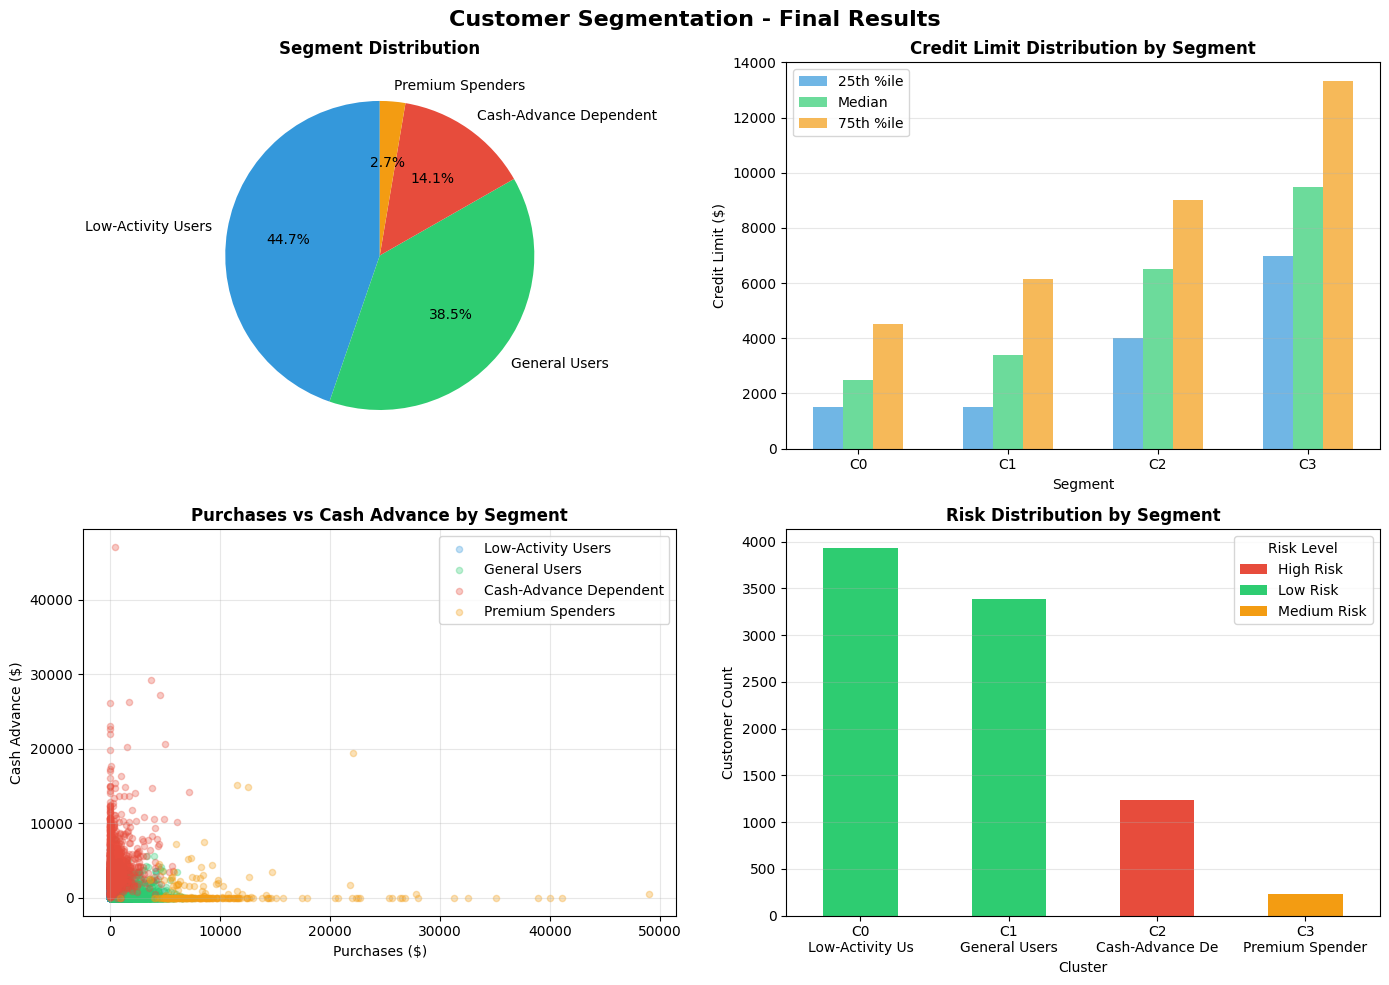

In [50]:
# ===============================================
# Final Segment Visualization
# ===============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Segmentation - Final Results', fontsize=16, fontweight='bold')

# Plot 1: Segment Distribution
ax1 = axes[0, 0]
segment_names = [segment_profiles_clean[i]['segment_name'] for i in range(4)]
segment_sizes = [segment_profiles_clean[i]['size_pct'] for i in range(4)]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

ax1.pie(segment_sizes, labels=segment_names, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Segment Distribution', fontweight='bold')

# Plot 2: Credit Limit Ranges
ax2 = axes[0, 1]
segments = range(4)
p25 = [segment_profiles_clean[i]['credit_limit_25th'] for i in range(4)]
p50 = [segment_profiles_clean[i]['credit_limit_median'] for i in range(4)]
p75 = [segment_profiles_clean[i]['credit_limit_75th'] for i in range(4)]

x = np.arange(4)
ax2.bar(x - 0.2, p25, 0.2, label='25th %ile', color='#3498db', alpha=0.7)
ax2.bar(x, p50, 0.2, label='Median', color='#2ecc71', alpha=0.7)
ax2.bar(x + 0.2, p75, 0.2, label='75th %ile', color='#f39c12', alpha=0.7)
ax2.set_xlabel('Segment')
ax2.set_ylabel('Credit Limit ($)')
ax2.set_title('Credit Limit Distribution by Segment', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f"C{i}" for i in range(4)])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Purchases vs Cash Advance
ax3 = axes[1, 0]
for cluster_id in range(4):
    cluster_data = df[df['CLUSTER'] == cluster_id]
    ax3.scatter(cluster_data['PURCHASES'], cluster_data['CASH_ADVANCE'],
                alpha=0.3, s=20, label=segment_profiles_clean[cluster_id]['segment_name'],
                color=colors[cluster_id])
ax3.set_xlabel('Purchases ($)')
ax3.set_ylabel('Cash Advance ($)')
ax3.set_title('Purchases vs Cash Advance by Segment', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Risk Distribution
ax4 = axes[1, 1]
risk_counts = df.groupby(['CLUSTER', 'RISK_LEVEL']).size().unstack(fill_value=0)
risk_counts.plot(kind='bar', stacked=True, ax=ax4,
                 color={'Low Risk': '#2ecc71', 'Medium Risk': '#f39c12', 'High Risk': '#e74c3c'})
ax4.set_xlabel('Cluster')
ax4.set_ylabel('Customer Count')
ax4.set_title('Risk Distribution by Segment', fontweight='bold')
ax4.set_xticklabels([f"C{i}\n{segment_profiles_clean[i]['segment_name'][:15]}" for i in range(4)], rotation=0)
ax4.legend(title='Risk Level')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4.3 - Business Impact Summary

### Key Achievements

**Segmentation:**
- Identified 4 distinct customer segments with clear behavioral patterns
- 83% of customers (Low-Activity + General Users) are low risk
- 14% (Cash-Advance Dependent) require restrictive credit management
- 2.7% (Premium Spenders) represent high-value opportunity

**Risk Management:**
- Individual risk scoring (3 behavioral factors) complements segment-level risk
- High-risk segment customers limited to 25th percentile ($4,000) regardless of individual score
- Low-risk segment customers benefit from generous limits (up to 75th percentile)

**Operational Value:**
- Automated credit decisions reduce manual review time
- Consistent, data-driven approach eliminates subjective bias
- Optimizes revenue opportunity with default risk
- Scalable to new customer applications
- Dashboard enables real-time what-if analysis


### Recommendation System Performance

**Credit Limit Logic:**

In [47]:
# ===============================================
# Recommendation System Summary
# ===============================================

print("="*70)
print("CREDIT LIMIT RECOMMENDATION BANDS")
print("="*70)

for cluster_id in range(4):
    profile = segment_profiles_clean[cluster_id]

    # Determine band based on risk
    if profile['risk_level'] == 'Low Risk':
        low, high = profile['credit_limit_median'], profile['credit_limit_75th']
        strategy = "Median → 75th percentile (encouraging growth)"
    elif profile['risk_level'] == 'Medium Risk':
        low, high = profile['credit_limit_25th'], profile['credit_limit_median']
        strategy = "25th → 50th percentile (balanced approach)"
    else:
        low, high = profile['credit_limit_25th'], profile['credit_limit_25th']
        strategy = "Fixed at 25th percentile (conservative)"

    print(f"\n{profile['segment_name']} ({profile['risk_level']}):")
    print(f"  Credit Band: ${low:,.0f} - ${high:,.0f}")
    print(f"  Strategy: {strategy}")
    print(f"  Applies to: {profile['size']:,} customers ({profile['size_pct']:.1f}%)")

print("\n" + "="*70)

CREDIT LIMIT RECOMMENDATION BANDS

Low-Activity Users (Low Risk):
  Credit Band: $2,500 - $4,500
  Strategy: Median → 75th percentile (encouraging growth)
  Applies to: 3,935 customers (44.7%)

General Users (Low Risk):
  Credit Band: $3,400 - $6,150
  Strategy: Median → 75th percentile (encouraging growth)
  Applies to: 3,390 customers (38.5%)

Cash-Advance Dependent (High Risk):
  Credit Band: $4,000 - $4,000
  Strategy: Fixed at 25th percentile (conservative)
  Applies to: 1,240 customers (14.1%)

Premium Spenders (Medium Risk):
  Credit Band: $7,000 - $9,500
  Strategy: 25th → 50th percentile (balanced approach)
  Applies to: 234 customers (2.7%)



### Steps for Production Deployment

**Deployment Path:**
1. Local validation → All test cases passed
2. GitHub repository → Code review & version control
3. Hugging Face Spaces → Public demo deployment

**Files Generated:**
- `dashboard/app.py` - Complete Shiny application
- `dashboard/TESTING.md` - Test procedures and validation
- `dashboard/requirements.txt` - Dependencies
- Model artifacts: kmeans_model.pkl, scaler.pkl, segment_profiles.json, etc.

## 4.4 - Project Completion Summary

In [49]:
# ===============================================
# PROJECT COMPLETION CHECKLIST
# ===============================================

print("\n" + "="*70)
print("PROJECT COMPLETION STATUS")
print("="*70)

deliverables = {
    "PHASE 0 - Data Preparation": [
        ("✓", "Data loading and quality validation"),
        ("✓", "Exploratory data analysis"),
        ("✓", "Feature engineering and selection")
    ],
    "PHASE 1 - Customer Segmentation": [
        ("✓", "K-Means model training (k=3-10)"),
        ("✓", "Model comparison (Silhouette + Davies-Bouldin)"),
        ("✓", "Final k=4 model selection"),
        ("✓", "Segment characterization and naming"),
        ("✓", "Risk level assignment")
    ],
    "PHASE 2 - Recommendation Engine": [
        ("✓", "Individual risk scoring logic"),
        ("✓", "Credit band mapping per segment"),
        ("✓", "CreditLimitRecommender class"),
        ("✓", "Model persistence (pickle + JSON)")
    ],
    "PHASE 3 - Deployment": [
        ("✓", "Interactive dashboard (Shiny)"),
        ("✓", "Default values (median General Users)"),
        ("✓", "Test cases (mean per segment)"),
        ("✓", "Testing documentation"),
    ],
    "PHASE 4 - Results": [
        ("✓", "Performance metrics documented"),
        ("✓", "Segment visualization"),
        ("✓", "Business impact analysis"),
        ("✓", "Deployment readiness")
    ]
}

for phase, tasks in deliverables.items():
    print(f"\n{phase}:")
    for status, task in tasks:
        print(f"  {status} {task}")


PROJECT COMPLETION STATUS

PHASE 0 - Data Preparation:
  ✓ Data loading and quality validation
  ✓ Exploratory data analysis
  ✓ Feature engineering and selection

PHASE 1 - Customer Segmentation:
  ✓ K-Means model training (k=3-10)
  ✓ Model comparison (Silhouette + Davies-Bouldin)
  ✓ Final k=4 model selection
  ✓ Segment characterization and naming
  ✓ Risk level assignment

PHASE 2 - Recommendation Engine:
  ✓ Individual risk scoring logic
  ✓ Credit band mapping per segment
  ✓ CreditLimitRecommender class
  ✓ Model persistence (pickle + JSON)

PHASE 3 - Deployment:
  ✓ Interactive dashboard (Shiny)
  ✓ Default values (median General Users)
  ✓ Test cases (mean per segment)
  ✓ Testing documentation

PHASE 4 - Results:
  ✓ Performance metrics documented
  ✓ Segment visualization
  ✓ Business impact analysis
  ✓ Deployment readiness
